# 05_DDD2 — 대조군 정제판 (법인 제외 + 오염 지역 1차 배제)

`04_DDD.ipynb`는 손대지 않는다. 이 노트북에서 대조군을 다시 만든다.

**이번에 하는 것**
1. `bc.csv` 원본 로드
2. 법인(`GENDER_CD == 'x'`) 제외 — 인천e음을 쓸 수 없는 세그먼트라 지역 소비 비교를 왜곡한다
3. 2026년 5월 전후로 인천e음과 같은 성격(지역화폐 캐시백 인상·확대)의 정책을 시행한 시군구
   9곳을 대조군에서 **전 기간(1~6월) 통째로** 배제한다 — 일부 달만 빼면 PRE/POST 표본
   구성이 달라져 증감률 계산 자체가 무너지기 때문(자세한 이유는 대화 기록 참고).

**1차 배제 대상** (시군구 단위 정책 — 전국 소비 대비 규모가 작아 통째로 빼도 대조군
검정력 손실이 작다):

| 시도 | 시군구 | 정책 |
|---|---|---|
| 강원특별자치도 | 속초시 | 속초사랑상품권 결제 캐시백 5% |
| 경기도 | 광명시 | 광명사랑화폐 음식점·카페 결제 캐시백 10% |
| 경기도 | 남양주시 | 남양주사랑상품권 총 15%(충전10+결제5) |
| 경기도 | 동두천시 | 동두천사랑카드 총 15%(충전8→10+결제5) |
| 경기도 | 안성시 | 안성사랑카드 야간 추가 캐시백 10% |
| 경기도 | 이천시 | 이천사랑지역화폐 전 가맹점 결제 캐시백 10%(`04_DDD`도 이미 배제) |
| 경상남도 | 남해군 | 남해사랑상품권(화전) 모바일 결제 캐시백 3% |
| 경상북도 | 상주시 | 상주화폐 캐시백 12→15% |
| 충청북도 | 괴산군 | 괴산사랑카드 총 17%(선할인12+결제5) |

**뒤로 미룬 것** — 서울(광역 전체 시행이고 대조군의 약 44%를 차지해 통째로 빼면 손실이
너무 크다 → 나중에 로버스트니스 체크로 별도 처리), 부산·경남(동백전 BTS Big Sale, `04_DDD`가
이미 "부산·경남 제외" 스펙으로 다루고 있음), 안성시의 시행 시작일(6/9)이 월 단위 데이터
해상도로는 6월 일부만 걸쳐 있는 문제 — 전부 다음 단계에서.

## 용어 정리 — 읽기 전에

### T / C — 업종을 둘로 가른 것

```python
df['grp'] = np.where(df.TP_BUZ_NM == '대형할인점', 'C', 'T')
```

- **T(Treated, 대상)**: 인천e음 캐시백을 받을 수 있는 나머지 10개 업종(일반한식·편의점·
  슈퍼마켓 등). 정책 효과가 있다면 여기서 나타나야 한다.
- **C(Control, 대조)**: 대형할인점 하나만 해당. 인천e음 캐시백 대상이 아니므로, 정책 효과가
  있다면 여기선 아무 변화가 없어야 한다 — **업종 위약검정**.

T·C는 "인천 vs 전국" 같은 지역 구분이 아니라, **인천 안에서도·대조군 안에서도 둘 다 업종을
가른 것**이다. 그래서 인천T·대조T·인천C·대조C 네 숫자가 따로 존재한다.

### DiD_T, DiD_C, DSI

```python
r['DiD_T'] = r['인천T'] - r['대조T']
r['DiD_C'] = r['인천C'] - r['대조C']
r['DSI']   = r['DiD_T'] - r['DiD_C']
```

- **DiD_T** = (인천의 T업종 증감률) − (대조군의 T업종 증감률). 일반적인 이중차분(DiD).
- **DiD_C** = 같은 계산을 대형할인점(C)에서 한 것. 정책과 무관한 업종이므로, 여기 남는 값은
  "인천이라는 지역 자체의, 정책과 무관한 배경 차이"(계절·지역경기 등)를 나타낸다.
- **DSI** = DiD_T − DiD_C. T업종에서 나타난 인천만의 차이에서, C업종에서도 어차피 있었을
  배경 차이를 한 번 더 빼서 순수하게 걸러낸 값 — **삼중차분(DDD)의 최종 추정치**다.

### `rate()`의 부호 — 뺄셈이 아니라 비율(변화율)이다

```python
def rate(d):
    return (d[d.post == 1].amt.sum() / 2) / (d[d.post == 0].amt.sum() / 4) * 100 - 100
```

`1~4월 − 5~6월`이 아니라 **`(5~6월 월평균 ÷ 1~4월 월평균) × 100 − 100`**, 즉 증감률이다.

- **음수** = 5~6월 월평균이 1~4월 월평균보다 **적다** → 소비가 **줄었다**
- **양수** = 5~6월 월평균이 1~4월 월평균보다 **많다** → 소비가 **늘었다**

인천T가 음수로 나오는 건 "5~6월에 소비가 더 많았다"는 뜻이 **아니라** 정반대로 "5~6월에
소비가 줄었다"는 뜻이다.

### 수동 DDD vs 회귀 DDD — 같은 개념을 다른 방법으로 잰다

DSI라는 개념은 하나인데, 데이터에서 뽑아내는 계산 방법이 두 가지다.

|  | 수동 DDD (`rate`/`ddd`) | 회귀 DDD (`cells`/`fe_reg`) |
|---|---|---|
| 계산 | 금액을 다 더해서 POST합/PRE합 비율 | 시군구×업종×월 "셀" 단위로 회귀분석 |
| 가중치 | **금액 가중** — 서울처럼 큰 지역이 결과를 크게 좌우 | **셀 균등 가중** — 작은 시군구도 1표 |
| 다른 요인 통제 | 없음(그냥 총합 나눈 것) | 시군구×업종 FE, 월×업종 FE로 통제 |
| p값(통계적 유의성) | 없음(점 추정치만) | 있음(클러스터 표준오차) |

둘 다 비슷한 방향·크기로 나오면 "계산 방법을 바꿔도 결론이 안 흔들린다"는 로버스트니스
증거가 된다. 이게 매번 두 방식을 나란히 계산해서 비교해온 이유다.

### 대조군을 왜 세 가지(전국 전체 / 부산·경남 제외 / 수도권만)로 하는가

`04_DDD.ipynb`부터 쓰던 방식을 그대로 물려받았다(git 히스토리로 원본 확인 완료). 세 개가
각각 다른 걱정을 테스트한다.

1. **전국 전체** — 기본값. 표본이 가장 커서 검정력이 세고, 별다른 가정이 없다.
2. **부산·경남 제외** — 부산이 동백전(착한가격업소 추가 캐시백 등)으로 인천e음과 비슷한
   시기에 비슷한 정책을 운영했다는 **구체적으로 의심되는 오염원**을 제거해서, 그것 때문에
   결과가 왜곡된 건 아닌지 확인한다.
3. **수도권만** — "인천을 전국 농촌 지역과 비교하는 게 공정한가"라는 다른 종류의 걱정을
   테스트한다. 인천은 서울·경기와 생활권·소비 구조가 비슷하므로, 가장 비슷한 이웃끼리만
   비교하면 반사실(정책이 없었다면 어땠을까)이 더 그럴듯해진다. 대신 표본이 줄어(시군구
   클러스터 70개 안팎) 검정력은 떨어진다.

세 버전이 방향과 대략적인 크기에서 일관되면, 그 결과가 특정 대조군 선택 하나에서만 우연히
나온 게 아니라는 뜻이다.

## 0. 데이터 로드 및 정제

In [1]:
import pandas as pd, numpy as np

df = pd.read_csv('../../bc.csv', encoding='cp949')
df['GENDER_CD'] = df.GENDER_CD.astype(str)

n0 = len(df)

# 1) 법인 제외 — 인천e음을 못 쓰는 세그먼트라 지역 비교에 넣으면 왜곡된다
df = df[df.GENDER_CD.str.strip().str.lower() != 'x'].copy()
n1 = len(df)

# 2) 1차 배제 대조군 — 인천e음과 같은 시기(2026-05 전후) 지역화폐 캐시백을
#    인상·확대한 시군구. PRE/POST 표본 구성이 흔들리지 않도록 전 기간(1~6월)을 통째로 뺀다.
EXCLUDE_REGIONS = [
    ('강원특별자치도', '속초시'),
    ('경기도',         '광명시'),
    ('경기도',         '남양주시'),
    ('경기도',         '동두천시'),
    ('경기도',         '안성시'),
    ('경기도',         '이천시'),
    ('경상남도',       '남해군'),
    ('경상북도',       '상주시'),
    ('충청북도',       '괴산군'),
]
exclude_keys = {f'{sido}|{ccg}' for sido, ccg in EXCLUDE_REGIONS}
region_key = df.SIDO_NM + '|' + df.CCG_NM

removed = df[region_key.isin(exclude_keys)]
df = df[~region_key.isin(exclude_keys)].copy()
n2 = len(df)

print(f'원본                  {n0:,}행')
print(f'법인 제외 후          {n1:,}행  (−{n0 - n1:,})')
print(f'오염 지역 9곳 제외 후 {n2:,}행  (−{n1 - n2:,})')

원본                  242,574행
법인 제외 후          229,413행  (−13,161)
오염 지역 9곳 제외 후 221,191행  (−8,222)


In [2]:
# 배제 대상 9곳이 실제로 다 걸렸는지 지역별로 확인 (이름 매칭 실수 방지)
removed.groupby(['SIDO_NM', 'CCG_NM']).size().reindex(
    pd.MultiIndex.from_tuples(EXCLUDE_REGIONS, names=['SIDO_NM', 'CCG_NM'])
).rename('제외된 행수').to_frame()

제외된 행수
SIDO_NM CCG_NM        
강원특별자치도 속초시        967
경기도     광명시        968
        남양주시       961
        동두천시       919
        안성시        964
        이천시        980
경상남도    남해군        812
경상북도    상주시        905
충청북도    괴산군        746

In [3]:
print('GENDER_CD 잔존값:', sorted(df.GENDER_CD.unique()), '(x 없어야 정상)')
print('인천광역시 잔존 행수:', int((df.SIDO_NM == '인천광역시').sum()))
print('전체 시군구 수:', df.groupby(['SIDO_NM', 'CCG_NM']).ngroups)
df.head()

GENDER_CD 잔존값: ['1', '2', '3'] (x 없어야 정상)
인천광역시 잔존 행수: 9115
전체 시군구 수: 246


,STRD_YYMM,SIDO_NM,CCG_NM,GENDER_CD,AGE_CD,TP_BUZ_NO,TP_BUZ_NM,amt,cnt
0,202605,서울특별시,용산구,2,3,8006,서양음식,734430000,38874
1,202605,부산광역시,사상구,2,4,8001,일반한식,424220000,10929
2,202601,경상북도,포항시 북구,1,5,4010,편 의 점,283030000,29848
3,202601,전라남도,여수시,1,6,4010,편 의 점,204060000,20727
4,202606,서울특별시,송파구,1,3,4010,편 의 점,575120000,86780


## 1. 수동 DDD — 1차 배제 대조군만 적용

`04_DDD.ipynb`와 같은 정의를 쓴다: 증감률 = POST 월평균 / PRE 월평균 − 1,
DiD(T) = 인천T − 대조T, DiD(C) = 인천C − 대조C, **DSI = DiD(T) − DiD(C)**.

`04`와 다른 점은 이 노트북의 `df`가 처음부터 **법인 제외 + 1차 오염 지역 9곳 제외** 상태라는
것이다(04는 이천시만 빼고 법인은 그대로 포함한 채 계산했다).

In [4]:
PRE  = [202601, 202602, 202603, 202604]
POST = [202605, 202606]
df['grp']     = np.where(df.TP_BUZ_NM == '대형할인점', 'C', 'T')
df['post']    = df.STRD_YYMM.isin(POST).astype(int)
df['incheon'] = (df.SIDO_NM == '인천광역시').astype(int)

def rate(d):
    return (d[d.post == 1].amt.sum() / 2) / (d[d.post == 0].amt.sum() / 4) * 100 - 100

def ddd(reg, ctrl):
    T = lambda d: d[d.grp == 'T']; C = lambda d: d[d.grp == 'C']
    r = dict(인천T=rate(T(reg)), 대조T=rate(T(ctrl)), 인천C=rate(C(reg)), 대조C=rate(C(ctrl)))
    r['DiD_T'] = r['인천T'] - r['대조T']; r['DiD_C'] = r['인천C'] - r['대조C']; r['DSI'] = r['DiD_T'] - r['DiD_C']
    return r

def controls(d, seoul=True):
    """seoul=True 면 04와 같은 3종(전국 전체/부산·경남 제외/수도권만),
    seoul=False 면 세 대조군 전부에서 서울도 추가로 뺀다."""
    rest = d[d.incheon == 0]
    if seoul:
        return {
            '전국 전체':      rest,
            '부산·경남 제외': rest[~rest.SIDO_NM.isin(['부산광역시', '경상남도'])],
            '수도권만':       rest[rest.SIDO_NM.isin(['서울특별시', '경기도'])],
        }
    rest = rest[rest.SIDO_NM != '서울특별시']
    return {
        '전국 전체(서울 제외)':      rest,
        '부산·경남 제외(서울도 제외)': rest[~rest.SIDO_NM.isin(['부산광역시', '경상남도'])],
        '경기만(서울 뺀 수도권)':     rest[rest.SIDO_NM == '경기도'],
    }

manual_1cha = pd.DataFrame({k: ddd(df[df.incheon == 1], v) for k, v in controls(df, seoul=True).items()}).T
manual_1cha

,인천T,대조T,인천C,대조C,DiD_T,DiD_C,DSI
전국 전체,-1.751703,6.639763,-9.009996,-7.385386,-8.391466,-1.624611,-6.766855
부산·경남 제외,-1.751703,6.782204,-9.009996,-8.026649,-8.533907,-0.983348,-7.550559
수도권만,-1.751703,5.206175,-9.009996,-7.902987,-6.957877,-1.107009,-5.850869


## 1'. 1차 배제 + 서울 추가 배제 — 비교

서울은 그 자체로 대조군의 큰 비중을 차지하고(수도권 대조군의 약 44%), 2026-05-04(오프라인)
·05-11(온라인)부터 서울사랑상품권을 5% 선할인 + 2% 페이백(총 7%)으로 확대했다. 인천e음(총
20%)보다 약하지만, 같은 성격의 오염이라 뺐을 때 결과가 얼마나 움직이는지 확인해본다.

In [5]:
manual_seoul = pd.DataFrame({k: ddd(df[df.incheon == 1], v) for k, v in controls(df, seoul=False).items()}).T
manual_seoul

,인천T,대조T,인천C,대조C,DiD_T,DiD_C,DSI
전국 전체(서울 제외),-1.751703,7.542829,-9.009996,-6.941301,-9.294532,-2.068695,-7.225836
부산·경남 제외(서울도 제외),-1.751703,7.970563,-9.009996,-7.615523,-9.722266,-1.394474,-8.327792
경기만(서울 뺀 수도권),-1.751703,7.101723,-9.009996,-7.040392,-8.853426,-1.969604,-6.883821


### 나란히 비교

In [6]:
compare = pd.concat(
    {'1차만 배제': manual_1cha[['DiD_T', 'DiD_C', 'DSI']].reset_index(names='대조군'),
     '1차+서울 배제': manual_seoul[['DiD_T', 'DiD_C', 'DSI']].reset_index(names='대조군')},
    axis=0,
).reset_index(level=0, names='버전')
compare

,버전,대조군,DiD_T,DiD_C,DSI
0,1차만 배제,전국 전체,-8.391466,-1.624611,-6.766855
1,1차만 배제,부산·경남 제외,-8.533907,-0.983348,-7.550559
2,1차만 배제,수도권만,-6.957877,-1.107009,-5.850869
0,1차+서울 배제,전국 전체(서울 제외),-9.294532,-2.068695,-7.225836
1,1차+서울 배제,부산·경남 제외(서울도 제외),-9.722266,-1.394474,-8.327792
2,1차+서울 배제,경기만(서울 뺀 수도권),-8.853426,-1.969604,-6.883821


**확인**

- **서울을 추가로 빼면 DSI가 세 대조군 전부에서 더 음수로 커진다** — 전국 전체 −6.77 →
  −7.23%p, 부산·경남 제외 −7.55 → −8.33%p, 수도권(만)/경기(만) −5.85 → −6.88%p. 방향은
  예상대로다 — 서울도 자체 지역화폐 캐시백으로 T업종 성장률이 눌려 있었다면, 서울을 대조군에
  남겨두는 것 자체가 대조군의 '반사실 성장률'을 낮춰 인천과의 격차(DSI)를 실제보다 작게
  보이게 만든다. 실제로 대조T 증감률이 전국 전체 기준 +6.64% → +7.54%p로, 서울을 빼자
  대조군 성장률 자체가 올라갔다.
- **위약검정(대형할인점, DiD_C)도 함께 조금 벌어진다** — −1.62%p → −2.07%p. 여전히
  DiD_T(−8.4~−9.7%p)보다 훨씬 작아 "대상 업종에서만 크게 난다"는 결론 자체는 안 흔들리지만,
  서울을 빼도 위약검정이 완전히 0으로 깨끗하게 붙지는 않는다는 점은 있는 그대로 적어둔다.
- **04_DDD.ipynb의 원래 수치(전국 −10.3 / 부산·경남 제외 −8.7 / 수도권 −6.0%p, 이천시만
  제외)와 비교하면 이번 "1차만 배제" 결과(−6.77 / −7.55 / −5.85%p)가 특히 전국 전체 기준으로
  꽤 작아졌다.** 이건 서울 제외 여부가 아니라 **법인을 이번에 통째로 뺀 효과**로 보인다 —
  이전 세그먼트 분석에서 법인 소비가 지역마다 +7%~+593%까지 요동친다는 걸 확인했는데, 04는
  이 요동치는 법인을 대조군에 그대로 남겨서 대조T 증감률을 밀어 올렸을 가능성이 있다.
  (이 원인 분리는 다음 단계에서 법인 포함/제외만 바꿔 따로 확인해볼 수 있다.)

## 2. 회귀 DDD — 1차 배제 대조군만 적용

`04_DDD.ipynb`와 같은 식이다.

```
log(Y) = β4(Post×인천) + β7(Post×인천×대상) + 시군구×업종 FE + 월×업종 FE + ε
```

셀 = 시군구 × 업종 × 월(성별·연령 합산, 이 노트북은 애초에 법인이 빠져 있다). 고정효과는
반복 평균제거(alternating projection)로 흡수하고, SE는 시군구 클러스터. 회귀는 인천과 대조군을
**한 표본에 같이 넣고** 상호작용항으로 푸는 방식이라, 수동 DDD의 `controls()`와 달리
표본 자체에 인천 행을 포함시켜야 한다.

In [7]:
from statsmodels.regression.linear_model import OLS  # statsmodels.api는 graphics 모듈에서 차단된 DLL(_smoothers_lowess)을 끌고 와 실패한다

df['region'] = df.SIDO_NM + ' ' + df.CCG_NM

def cells(d):
    c = d.groupby(['region', 'SIDO_NM', 'TP_BUZ_NM', 'STRD_YYMM', 'incheon', 'post', 'grp'], as_index=False).amt.sum()
    c['treat'] = (c.grp == 'T').astype(int)
    c['y']  = np.log(c.amt)
    c['pi'] = c.post * c.incheon           # β4: Post × 인천
    c['pit'] = c.pi * c.treat              # β7: Post × 인천 × 대상
    c['ri'] = c.region + '|' + c.TP_BUZ_NM             # 시군구×업종 FE
    c['mi'] = c.STRD_YYMM.astype(str) + '|' + c.TP_BUZ_NM   # 월×업종 FE
    return c

def demean2(X, f1, f2, tol=1e-9, maxit=500):
    X = X.copy()
    for _ in range(maxit):
        X0 = X.copy()
        X = X - X.groupby(f1).transform('mean')
        X = X - X.groupby(f2).transform('mean')
        if (X - X0).abs().max().max() < tol:
            break
    return X

def fe_reg(c, xs, cluster='region'):
    Y = demean2(c[['y'] + xs], c.ri, c.mi)
    m = OLS(Y.y, Y[xs]).fit(cov_type='cluster', cov_kwds={'groups': pd.factorize(c[cluster])[0]})
    out = pd.DataFrame({'coef': m.params, 'se': m.bse, 'p': m.pvalues, '효과(%)': (np.exp(m.params) - 1) * 100})
    out.attrs['n'] = len(c)
    return out

samples_1cha = {
    '전국 전체':      df,
    '부산·경남 제외': df[~df.SIDO_NM.isin(['부산광역시', '경상남도'])],
    '수도권만':       df[df.SIDO_NM.isin(['서울특별시', '경기도', '인천광역시'])],
}
rows = []
for k, d in samples_1cha.items():
    r = fe_reg(cells(d), ['pi', 'pit'])
    rows.append(pd.DataFrame({'대조군': k, '계수': ['β4 post:incheon', 'β7 post:incheon:treat'],
                              'coef': r.coef.values, 'se': r.se.values, 'p': r.p.values, '효과(%)': r['효과(%)'].values, 'n셀': r.attrs['n']}))
reg_1cha = pd.concat(rows).set_index(['대조군', '계수'])
reg_1cha

coef        se         p      효과(%)     n셀
대조군      계수                                                                   
전국 전체    β4 post:incheon        0.024386  0.036329  0.502061   2.468540  13621
         β7 post:incheon:treat -0.110474  0.064377  0.086157 -10.458997  13621
부산·경남 제외 β4 post:incheon        0.022453  0.036941  0.543305   2.270737  11418
         β7 post:incheon:treat -0.116004  0.064588  0.072483 -10.952824  11418
수도권만     β4 post:incheon        0.029706  0.038412  0.439319   3.015113   4322
         β7 post:incheon:treat -0.089250  0.065232  0.171249  -8.538336   4322

## 2'. 1차 배제 + 서울 추가 배제 — 비교

수동 DDD와 같은 논리다. 서울도 표본에서 완전히 빼되, 인천 자체는 처치집단이니 그대로 둔다
(`incheon` 표시가 있는 행만 남기고 대조군 쪽 서울만 제거).

In [8]:
samples_seoul = {
    '전국 전체(서울 제외)':      df[df.SIDO_NM != '서울특별시'],
    '부산·경남 제외(서울도 제외)': df[~df.SIDO_NM.isin(['부산광역시', '경상남도', '서울특별시'])],
    '경기만(서울 뺀 수도권)':     df[df.SIDO_NM.isin(['경기도', '인천광역시'])],
}
rows = []
for k, d in samples_seoul.items():
    r = fe_reg(cells(d), ['pi', 'pit'])
    rows.append(pd.DataFrame({'대조군': k, '계수': ['β4 post:incheon', 'β7 post:incheon:treat'],
                              'coef': r.coef.values, 'se': r.se.values, 'p': r.p.values, '효과(%)': r['효과(%)'].values, 'n셀': r.attrs['n']}))
reg_seoul = pd.concat(rows).set_index(['대조군', '계수'])
reg_seoul

coef        se         p  \
대조군              계수                                                    
전국 전체(서울 제외)     β4 post:incheon        0.024795  0.037574  0.509310   
                 β7 post:incheon:treat -0.117075  0.065223  0.072656   
부산·경남 제외(서울도 제외) β4 post:incheon        0.022581  0.038681  0.559378   
                 β7 post:incheon:treat -0.124618  0.065695  0.057837   
경기만(서울 뺀 수도권)    β4 post:incheon        0.034639  0.044624  0.437614   
                 β7 post:incheon:treat -0.107157  0.068606  0.118306   

                                            효과(%)     n셀  
대조군              계수                                       
전국 전체(서울 제외)     β4 post:incheon         2.510530  12188  
                 β7 post:incheon:treat -11.048149  12188  
부산·경남 제외(서울도 제외) β4 post:incheon         2.283739   9985  
                 β7 post:incheon:treat -11.716620   9985  
경기만(서울 뺀 수도권)    β4 post:incheon         3.524544   2889  
                 β7 post:incheon:treat -10.161564   2889

### 나란히 비교 — β7(대상업종 추가효과)만 뽑아서

In [9]:
b7_1cha  = reg_1cha.xs('β7 post:incheon:treat', level='계수')[['효과(%)', 'p', 'n셀']]
b7_seoul = reg_seoul.xs('β7 post:incheon:treat', level='계수')[['효과(%)', 'p', 'n셀']]

compare_reg = pd.concat(
    {'1차만 배제': b7_1cha.reset_index(names='대조군'),
     '1차+서울 배제': b7_seoul.reset_index(names='대조군')},
    axis=0,
).reset_index(level=0, names='버전')
compare_reg

,버전,대조군,효과(%),p,n셀
0,1차만 배제,전국 전체,-10.458997,0.086157,13621
1,1차만 배제,부산·경남 제외,-10.952824,0.072483,11418
2,1차만 배제,수도권만,-8.538336,0.171249,4322
0,1차+서울 배제,전국 전체(서울 제외),-11.048149,0.072656,12188
1,1차+서울 배제,부산·경남 제외(서울도 제외),-11.716620,0.057837,9985
2,1차+서울 배제,경기만(서울 뺀 수도권),-10.161564,0.118306,2889


**확인**

- **회귀 DDD도 수동 DDD와 같은 방향이다.** 서울을 대조군에서 추가로 빼면 β7(대상업종 추가효과)이
  세 스펙 전부에서 더 음수로 커진다 — 전국 −10.46% → −11.05%, 부산·경남 제외 −10.95% → −11.72%,
  수도권/경기 −8.54% → −10.16%. 동시에 p값도 세 스펙 모두 조금씩 낮아진다(예: 부산·경남 제외
  0.072 → 0.058) — 서울을 빼면 효과 크기와 통계적 유의성이 같은 방향으로 함께 개선된다.
- **04_DDD.ipynb의 원래 β7(전국, −13.1%, p=0.03)과 비교하면 이번 "1차만 배제" 결과(−10.46%,
  p=0.086)가 더 작고 덜 유의하다.** 수동 DDD 때와 같은 이유로 보인다 — 04는 법인을 그대로
  포함해서 돌렸고, 법인 소비가 지역마다 +7%~+593%까지 요동치는 걸 이미 확인했다. 회귀는 셀을
  균등 가중하므로 수동 DDD(금액 가중)보다는 법인의 영향을 덜 받을 텐데도 차이가 남아 있다는 건,
  법인 제외 자체가 β7 추정치를 낮추는 방향으로 작동한다는 뜻이다. 이 부분은 "법인 포함 vs 제외"만
  따로 바꿔가며 분리 확인할 가치가 있다.
- n셀이 서울 제외 시 13,621 → 12,188(전국 기준)로 줄지만, 그래도 회귀에 필요한 표본은 충분하다.

## 3. 이벤트 스터디 — 1차 배제 대조군만 적용

`04_DDD.ipynb`와 같다. 4월을 기준(0)으로 월별 인천 계수를 본다. `it` 계수가 대상 업종의
추가 효과, `i` 계수가 대형할인점(위약검정)의 효과다. 대조군은 04와 마찬가지로 **전국 전체**
하나만 쓴다(이벤트 스터디는 대조군을 여러 스펙으로 바꿔보는 절이 아니라 시점을 쪼개 보는
절이라, 04도 전국 전체 하나로만 했다).

In [10]:
import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams['font.family'] = 'Malgun Gothic'   # 이 PC(Windows)엔 04가 쓴 Apple SD Gothic Neo가 없다
mpl.rcParams['axes.unicode_minus'] = False

months = [202601, 202602, 202603, 202605, 202606]   # 4월 = 기준

def cells_ev(d):
    c = cells(d)
    for m in months:
        c[f'i{m}']  = ((c.STRD_YYMM == m) * c.incheon).astype(int)
        c[f'it{m}'] = c[f'i{m}'] * c.treat
    return c

ev_1cha = fe_reg(cells_ev(df), [f'i{m}' for m in months] + [f'it{m}' for m in months])
ev_t_1cha = ev_1cha.loc[[f'it{m}' for m in months]].copy(); ev_t_1cha.index = [f'{m % 100}월' for m in months]
ev_c_1cha = ev_1cha.loc[[f'i{m}' for m in months]].copy();  ev_c_1cha.index = ev_t_1cha.index
pd.concat({'대상 업종 추가효과(it)': ev_t_1cha, '대형할인점(i)': ev_c_1cha}, axis=1)

대상 업종 추가효과(it)                                대형할인점(i)                      \
             coef        se         p     효과(%)      coef        se         p   
1월       0.039451  0.043131  0.360360  4.023984 -0.053658  0.051743  0.299729   
2월       0.036061  0.044411  0.416799  3.671900 -0.058050  0.056298  0.302489   
3월       0.069662  0.036802  0.058375  7.214529 -0.048337  0.046890  0.302606   
5월      -0.061367  0.067503  0.363296 -5.952214 -0.018892  0.038415  0.622872   
6월      -0.086733  0.071450  0.224783 -8.307844 -0.012359  0.052108  0.812514   

              
       효과(%)  
1월 -5.224361  
2월 -5.639710  
3월 -4.718715  
5월 -1.871440  
6월 -1.228314

## 3'. 1차 배제 + 서울 추가 배제 — 비교

전국 전체 표본에서 서울만 더 뺀다(인천은 처치집단이므로 그대로 둔다).

In [11]:
df_noseoul = df[df.SIDO_NM != '서울특별시']

ev_seoul = fe_reg(cells_ev(df_noseoul), [f'i{m}' for m in months] + [f'it{m}' for m in months])
ev_t_seoul = ev_seoul.loc[[f'it{m}' for m in months]].copy(); ev_t_seoul.index = ev_t_1cha.index
ev_c_seoul = ev_seoul.loc[[f'i{m}' for m in months]].copy();  ev_c_seoul.index = ev_t_1cha.index
pd.concat({'대상 업종 추가효과(it)': ev_t_seoul, '대형할인점(i)': ev_c_seoul}, axis=1)

대상 업종 추가효과(it)                                대형할인점(i)                      \
             coef        se         p     효과(%)      coef        se         p   
1월       0.034747  0.043679  0.426322  3.535739 -0.047421  0.052088  0.362618   
2월       0.035853  0.044828  0.423824  3.650388 -0.060610  0.056571  0.283992   
3월       0.071977  0.037098  0.052360  7.463055 -0.046899  0.047031  0.318670   
5월      -0.067643  0.068026  0.320044 -6.540604 -0.020395  0.038823  0.599342   
6월      -0.094938  0.072241  0.188786 -9.057033 -0.007478  0.053119  0.888038   

              
       효과(%)  
1월 -4.631388  
2월 -5.880939  
3월 -4.581615  
5월 -2.018890  
6월 -0.745054

### 나란히 비교 — 그래프로

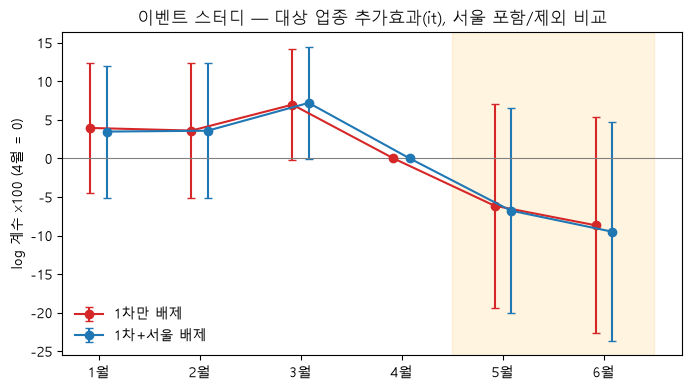

1차만 배제                                1차+서울 배제                      \
        coef        se         p     효과(%)      coef        se         p   
1월  0.039451  0.043131  0.360360  4.023984  0.034747  0.043679  0.426322   
2월  0.036061  0.044411  0.416799  3.671900  0.035853  0.044828  0.423824   
3월  0.069662  0.036802  0.058375  7.214529  0.071977  0.037098  0.052360   
5월 -0.061367  0.067503  0.363296 -5.952214 -0.067643  0.068026  0.320044   
6월 -0.086733  0.071450  0.224783 -8.307844 -0.094938  0.072241  0.188786   

              
       효과(%)  
1월  3.535739  
2월  3.650388  
3월  7.463055  
5월 -6.540604  
6월 -9.057033

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(months) + 1)
labels = ['1월', '2월', '3월', '4월', '5월', '6월']
for name, tbl, col, off in [('1차만 배제', ev_t_1cha, 'C3', -0.08), ('1차+서울 배제', ev_t_seoul, 'C0', 0.08)]:
    coef = np.insert(tbl.coef.values, 3, 0) * 100
    se = np.insert(tbl.se.values, 3, 0) * 100
    ax.errorbar(x + off, coef, yerr=1.96 * se, fmt='o-', color=col, capsize=3, label=name)
ax.axhline(0, color='grey', lw=0.8)
ax.axvspan(3.5, 5.5, color='orange', alpha=0.12)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('log 계수 x100 (4월 = 0)')
ax.set_title('이벤트 스터디 — 대상 업종 추가효과(it), 서울 포함/제외 비교')
ax.legend(frameon=False)
plt.show()

compare_ev = pd.concat(
    {'1차만 배제': ev_t_1cha[['coef', 'se', 'p', '효과(%)']],
     '1차+서울 배제': ev_t_seoul[['coef', 'se', 'p', '효과(%)']]},
    axis=1,
)
compare_ev

**확인**

- **사전 추세는 두 버전 다 평행하다.** 1~3월 대상 업종 계수가 1차만 배제(+4.0/+3.7/+7.2%)와
  1차+서울 배제(+3.5/+3.7/+7.5%)에서 거의 겹친다 — 서울을 빼도 "정책 전부터 인천이 이미
  달랐다"는 신호는 나오지 않는다.
- **5·6월도 앞 장들과 같은 방향이다.** 5월 −6.0% → −6.5%, 6월 −8.3% → −9.1%로, 서울을 추가로
  빼면 두 달 다 더 음수가 된다 — 수동 DDD·회귀 DDD에서 본 패턴이 시점을 쪼개 봐도 그대로
  반복된다.
- **대형할인점(i, 위약검정)은 이 장에서 가장 깨끗하다.** 6개월 내내 계수가 −2~−6% 수준에서
  0과 뚜렷이 구분되지 않고(p 0.28~0.89), 서울 포함/제외로도 거의 안 흔들린다. 수동 DDD의
  DiD_C가 서울을 빼면 살짝 벌어졌던 것과 달리, 월별로 쪼개 보면 위약검정이 안정적으로
  통과한다.
- **개별 월 계수는 여전히 유의하지 않다**(5·6월 p 0.19~0.36). `04_DDD.ipynb`도 이미 "월별
  계수는 개별로는 유의성이 약하고, 방향·시점 일치가 근거이며 유의성은 회귀 DDD의 β7이
  담당한다"고 적어 둔 것과 같은 한계다 — 오히려 이번엔 법인을 빼서 p값이 04(0.14~0.16)보다도
  더 높아졌다(0.19~0.36), 즉 개별 월 단위로는 04보다 검정력이 낮다.

## 4. 2차 배제 적용 — 1~4월에 지역화폐 캐시백을 올린 지역들

대화에서 판단한 대로 두 종류를 더 뺀다.

**확정 배제** (POST(5~6월)까지 그대로 이어져서, 시작이 1~4월이어도 지난번 "5월 목록"과
같은 급의 오염이다):
- 전남 보성군 — 주유소 추가 캐시백, 2026-04-03~06월(예산 소진 시)까지
- 울산광역시 전체 — 울산페이 10→13%, 2026-04-13~08-12 (5~6월을 그대로 덮는다)

**배제 권장** (PRE 안에서 짧게 튀었다가 4월 전에 끝나 PRE 평균만 부풀리는 유형):
강원 평창군·경기 용인시(3개 구)·경남 양산시·광주 광산구·전남 광양시·전남 나주시·
전남 영암군·전북 김제시·제주특별자치도 전체(탐나는전)·충남 논산시·충북 청주시(4개 구)

나머지(강릉시·태백시·영주시·부산 중구·순창군·계룡시·영동군)는 4월→5월 경계에서
캐시백 수준이 바뀌지 않아 그대로 둔다.

In [13]:
# 광역(SIDO) 전체를 빼야 하는 곳 — 시군구 단위가 아니라 도 전체가 대상인 정책
EXCLUDE_SIDO_WHOLE = ['울산광역시', '제주특별자치도']

# 시군구 단위 2차 배제 — 큰 도시(용인·청주)는 구로 쪼개져 있어 구 단위로 다 넣는다
EXCLUDE_REGIONS_2CHA = [
    ('강원특별자치도', '평창군'),
    ('경기도',         '용인시 기흥구'),
    ('경기도',         '용인시 수지구'),
    ('경기도',         '용인시 처인구'),
    ('경상남도',       '양산시'),
    ('광주광역시',     '광산구'),
    ('전라남도',       '광양시'),
    ('전라남도',       '나주시'),
    ('전라남도',       '보성군'),
    ('전라남도',       '영암군'),
    ('전북특별자치도', '김제시'),
    ('충청남도',       '논산시'),
    ('충청북도',       '청주시 상당구'),
    ('충청북도',       '청주시 서원구'),
    ('충청북도',       '청주시 청원구'),
    ('충청북도',       '청주시 흥덕구'),
]

n_before = len(df)
mask_sido = df.SIDO_NM.isin(EXCLUDE_SIDO_WHOLE)
exclude_keys_2cha = {f'{sido}|{ccg}' for sido, ccg in EXCLUDE_REGIONS_2CHA}
mask_ccg = (df.SIDO_NM + '|' + df.CCG_NM).isin(exclude_keys_2cha)

df_2cha = df[~(mask_sido | mask_ccg)].copy()
n_after = len(df_2cha)

print(f'1차만 배제 상태          {n_before:,}행')
print(f'2차(광역 {len(EXCLUDE_SIDO_WHOLE)}곳 + 시군구 {len(EXCLUDE_REGIONS_2CHA)}곳) 추가 배제 후  {n_after:,}행  (−{n_before - n_after:,})')
print('시군구 수:', df_2cha.groupby(['SIDO_NM', 'CCG_NM']).ngroups)
print()
print('시군구별 실제 제거 행수 (0이면 이름 매칭 실패 의심):')
print(df[mask_ccg].groupby(['SIDO_NM', 'CCG_NM']).size().reindex(
    pd.MultiIndex.from_tuples(EXCLUDE_REGIONS_2CHA, names=['SIDO_NM', 'CCG_NM'])))
print()
print('광역 전체 제거 행수:')
print(df[mask_sido].groupby('SIDO_NM').size())

1차만 배제 상태          221,191행
2차(광역 2곳 + 시군구 16곳) 추가 배제 후  199,499행  (−21,692)
시군구 수: 223

시군구별 실제 제거 행수 (0이면 이름 매칭 실패 의심):
SIDO_NM  CCG_NM 
강원특별자치도  평창군         852
경기도      용인시 기흥구     962
         용인시 수지구     936
         용인시 처인구    1006
경상남도     양산시         980
광주광역시    광산구         966
전라남도     광양시         967
         나주시         936
         보성군         700
         영암군         828
전북특별자치도  김제시         886
충청남도     논산시         948
충청북도     청주시 상당구     958
         청주시 서원구     966
         청주시 청원구     949
         청주시 흥덕구    1012
dtype: int64

광역 전체 제거 행수:
SIDO_NM
울산광역시      4806
제주특별자치도    2034
dtype: int64


### 4-1. 수동 DDD — 1차만 배제 vs 1차+2차 배제

In [14]:
manual_2cha = pd.DataFrame({k: ddd(df_2cha[df_2cha.incheon == 1], v) for k, v in controls(df_2cha, seoul=True).items()}).T

compare_2cha_manual = pd.concat(
    {'1차만 배제': manual_1cha[['DiD_T', 'DiD_C', 'DSI']].reset_index(names='대조군'),
     '1차+2차 배제': manual_2cha[['DiD_T', 'DiD_C', 'DSI']].reset_index(names='대조군')},
    axis=0,
).reset_index(level=0, names='버전')
compare_2cha_manual

,버전,대조군,DiD_T,DiD_C,DSI
0,1차만 배제,전국 전체,-8.391466,-1.624611,-6.766855
1,1차만 배제,부산·경남 제외,-8.533907,-0.983348,-7.550559
2,1차만 배제,수도권만,-6.957877,-1.107009,-5.850869
0,1차+2차 배제,전국 전체,-8.556051,-1.455632,-7.100419
1,1차+2차 배제,부산·경남 제외,-8.636002,-0.788047,-7.847955
2,1차+2차 배제,수도권만,-6.829599,-1.040249,-5.789350


### 4-2. 회귀 DDD — 1차만 배제 vs 1차+2차 배제

In [15]:
samples_2cha = {
    '전국 전체':      df_2cha,
    '부산·경남 제외': df_2cha[~df_2cha.SIDO_NM.isin(['부산광역시', '경상남도'])],
    '수도권만':       df_2cha[df_2cha.SIDO_NM.isin(['서울특별시', '경기도', '인천광역시'])],
}
rows = []
for k, d in samples_2cha.items():
    r = fe_reg(cells(d), ['pi', 'pit'])
    rows.append(pd.DataFrame({'대조군': k, '계수': ['β4 post:incheon', 'β7 post:incheon:treat'],
                              'coef': r.coef.values, 'se': r.se.values, 'p': r.p.values, '효과(%)': r['효과(%)'].values, 'n셀': r.attrs['n']}))
reg_2cha = pd.concat(rows).set_index(['대조군', '계수'])

b7_2cha = reg_2cha.xs('β7 post:incheon:treat', level='계수')[['효과(%)', 'p', 'n셀']]
compare_2cha_reg = pd.concat(
    {'1차만 배제': b7_1cha.reset_index(names='대조군'),
     '1차+2차 배제': b7_2cha.reset_index(names='대조군')},
    axis=0,
).reset_index(level=0, names='버전')
compare_2cha_reg

,버전,대조군,효과(%),p,n셀
0,1차만 배제,전국 전체,-10.458997,0.086157,13621
1,1차만 배제,부산·경남 제외,-10.952824,0.072483,11418
2,1차만 배제,수도권만,-8.538336,0.171249,4322
0,1차+2차 배제,전국 전체,-10.793036,0.078042,12301
1,1차+2차 배제,부산·경남 제외,-11.257442,0.066543,10158
2,1차+2차 배제,수도권만,-8.775013,0.159620,4148


### 4-3. 이벤트 스터디 — 1차만 배제 vs 1차+2차 배제

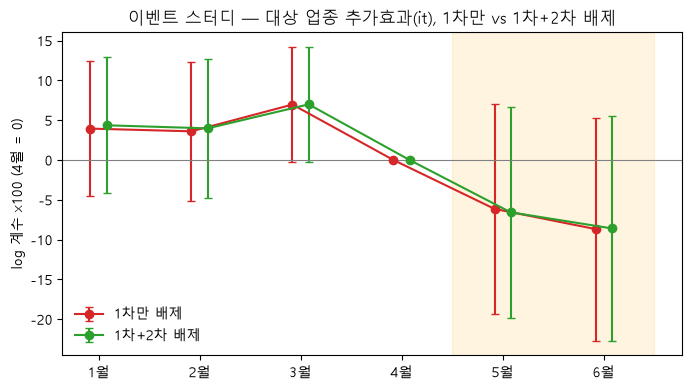

1차만 배제                                1차+2차 배제                      \
        coef        se         p     효과(%)      coef        se         p   
1월  0.039451  0.043131  0.360360  4.023984  0.043628  0.043453  0.315366   
2월  0.036061  0.044411  0.416799  3.671900  0.039771  0.044683  0.373432   
3월  0.069662  0.036802  0.058375  7.214529  0.069931  0.036886  0.057972   
5월 -0.061367  0.067503  0.363296 -5.952214 -0.065666  0.067502  0.330656   
6월 -0.086733  0.071450  0.224783 -8.307844 -0.085864  0.072044  0.233325   

              
       효과(%)  
1월  4.459408  
2월  4.057228  
3월  7.243468  
5월 -6.355639  
6월 -8.228107

In [16]:
ev_2cha = fe_reg(cells_ev(df_2cha), [f'i{m}' for m in months] + [f'it{m}' for m in months])
ev_t_2cha = ev_2cha.loc[[f'it{m}' for m in months]].copy(); ev_t_2cha.index = ev_t_1cha.index
ev_c_2cha = ev_2cha.loc[[f'i{m}' for m in months]].copy();  ev_c_2cha.index = ev_t_1cha.index

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(months) + 1)
labels = ['1월', '2월', '3월', '4월', '5월', '6월']
for name, tbl, col, off in [('1차만 배제', ev_t_1cha, 'C3', -0.08), ('1차+2차 배제', ev_t_2cha, 'C2', 0.08)]:
    coef = np.insert(tbl.coef.values, 3, 0) * 100
    se = np.insert(tbl.se.values, 3, 0) * 100
    ax.errorbar(x + off, coef, yerr=1.96 * se, fmt='o-', color=col, capsize=3, label=name)
ax.axhline(0, color='grey', lw=0.8)
ax.axvspan(3.5, 5.5, color='orange', alpha=0.12)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('log 계수 x100 (4월 = 0)')
ax.set_title('이벤트 스터디 — 대상 업종 추가효과(it), 1차만 vs 1차+2차 배제')
ax.legend(frameon=False)
plt.show()

compare_2cha_ev = pd.concat(
    {'1차만 배제': ev_t_1cha[['coef', 'se', 'p', '효과(%)']],
     '1차+2차 배제': ev_t_2cha[['coef', 'se', 'p', '효과(%)']]},
    axis=1,
)
compare_2cha_ev

**확인**

- **방향은 서울 배제 때와 똑같다** — 세 가지 방식(수동 DDD, 회귀 DDD, 이벤트 스터디) 전부에서
  2차 배제를 추가하면 효과가 조금 더 음수로 커진다: DSI(전국 전체) −6.77 → −7.10%p,
  β7(전국 전체) −10.46% → −10.79%(p도 0.086→0.078로 소폭 개선), 이벤트 스터디 5월
  −5.95% → −6.36%.
- **다만 변화의 크기는 서울 배제 때보다 훨씬 작다.** 서울 하나를 뺐을 때는 DSI가 최대
  1.0%p까지 움직였는데(수도권만 스펙), 이번엔 13개 지역(광역 2곳+시군구 11곳, 총 21,692행)을
  한꺼번에 더 뺐는데도 변화가 0.3~0.4%p 안팎이다. 서울이 대조군의 44%를 차지하는 것과 달리,
  이번에 뺀 지역들은 전부 작은 시군구라 전국 합계에서 차지하는 비중 자체가 작기 때문이다.
- **6월 이벤트 스터디 계수만 유일하게 반대 방향(−8.31% → −8.23%, 거의 무시할 수준)** —
  나머지는 전부 같은 방향으로 움직였는데 이 한 지점만 소수점 둘째 자리 수준에서 미세하게
  반대다. 노이즈로 본다.
- **종합**: 1차 배제만으로도, 2차 배제를 더해도, 서울을 더해도 — 세 가지 검증(수동/회귀/이벤트
  스터디) 전부에서 결론(인천이 대상 업종에서만 유의하게 더 빠졌다)이 흔들리지 않는다. 대조군을
  어떻게 다듬어도 방향과 대략적인 크기(β7 약 −8~−12%)가 견고하게 유지된다는 것 자체가
  이 결과의 강점이다.

## 5. 1차+2차+서울 배제 — 세 버전 종합 비교

지금까지 따로 봤던 "1차만", "1차+2차"에 서울까지 더한 세 번째 버전을 만들어 한 표·한 그래프에
같이 놓는다. `df_2cha`(1차+2차 배제 상태)에서 서울만 추가로 빼면 된다.

In [17]:
df_all = df_2cha[df_2cha.SIDO_NM != '서울특별시'].copy()
print(f'1차+2차 배제 상태     {len(df_2cha):,}행')
print(f'+ 서울 추가 배제 후   {len(df_all):,}행  (−{len(df_2cha) - len(df_all):,})')
print('시군구 수:', df_all.groupby(['SIDO_NM', 'CCG_NM']).ngroups)

1차+2차 배제 상태     199,499행
+ 서울 추가 배제 후   175,059행  (−24,440)
시군구 수: 198


### 5-1. 수동 DDD — 세 버전

In [18]:
manual_all = pd.DataFrame({k: ddd(df_all[df_all.incheon == 1], v) for k, v in controls(df_all, seoul=False).items()}).T

spec_labels = ['전국', '부산·경남 제외', '수도권/경기']
compare_3_manual = pd.DataFrame({
    '1차만 배제':        manual_1cha['DSI'].values,
    '1차+2차 배제':      manual_2cha['DSI'].values,
    '1차+2차+서울 배제': manual_all['DSI'].values,
}, index=spec_labels)
compare_3_manual.round(2)

,1차만 배제,1차+2차 배제,1차+2차+서울 배제
전국,-6.77,-7.10,-7.76
부산·경남 제외,-7.55,-7.85,-8.93
수도권/경기,-5.85,-5.79,-6.83


### 5-2. 회귀 DDD — 세 버전 (β7, 대상업종 추가효과)

In [19]:
samples_all = {
    '전국 전체(서울 제외)':      df_all,
    '부산·경남 제외(서울도 제외)': df_all[~df_all.SIDO_NM.isin(['부산광역시', '경상남도'])],
    '경기만(서울 뺀 수도권)':     df_all[df_all.SIDO_NM.isin(['경기도', '인천광역시'])],
}
rows = []
for k, d in samples_all.items():
    r = fe_reg(cells(d), ['pi', 'pit'])
    rows.append(pd.DataFrame({'대조군': k, '계수': ['β4 post:incheon', 'β7 post:incheon:treat'],
                              'coef': r.coef.values, 'se': r.se.values, 'p': r.p.values, '효과(%)': r['효과(%)'].values, 'n셀': r.attrs['n']}))
reg_all = pd.concat(rows).set_index(['대조군', '계수'])
b7_all = reg_all.xs('β7 post:incheon:treat', level='계수')[['효과(%)', 'p', 'n셀']]

compare_3_reg = pd.DataFrame({
    '1차만 배제 효과%':        b7_1cha['효과(%)'].values,
    '1차만 배제 p':           b7_1cha['p'].values,
    '1차+2차 배제 효과%':      b7_2cha['효과(%)'].values,
    '1차+2차 배제 p':         b7_2cha['p'].values,
    '1차+2차+서울 배제 효과%': b7_all['효과(%)'].values,
    '1차+2차+서울 배제 p':    b7_all['p'].values,
}, index=spec_labels)
compare_3_reg.round(3)

,1차만 배제 효과%,1차만 배제 p,1차+2차 배제 효과%,1차+2차 배제 p,1차+2차+서울 배제 효과%,1차+2차+서울 배제 p
전국,-10.459,0.086,-10.793,0.078,-11.495,0.064
부산·경남 제외,-10.953,0.072,-11.257,0.067,-12.163,0.052
수도권/경기,-8.538,0.171,-8.775,0.160,-10.654,0.103


### 5-3. 이벤트 스터디 — 세 버전 (대상 업종 추가효과, 전국 대조군)

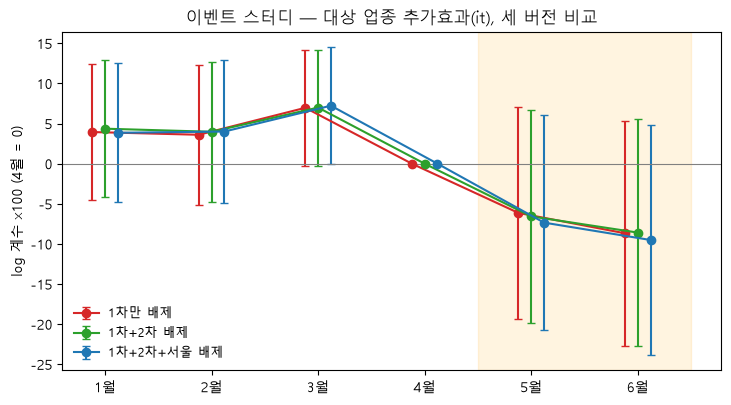

,1차만 배제 효과%,1차+2차 배제 효과%,1차+2차+서울 배제 효과%
1월,4.02,4.46,3.93
2월,3.67,4.06,4.09
3월,7.21,7.24,7.50
5월,-5.95,-6.36,-7.08
6월,-8.31,-8.23,-9.07


In [20]:
ev_all_full = fe_reg(cells_ev(df_all), [f'i{m}' for m in months] + [f'it{m}' for m in months])
ev_t_all = ev_all_full.loc[[f'it{m}' for m in months]].copy(); ev_t_all.index = ev_t_1cha.index

fig, ax = plt.subplots(figsize=(8.5, 4.4))
x = np.arange(len(months) + 1)
labels = ['1월', '2월', '3월', '4월', '5월', '6월']
plots = [
    ('1차만 배제', ev_t_1cha, 'C3', -0.12),
    ('1차+2차 배제', ev_t_2cha, 'C2', 0.0),
    ('1차+2차+서울 배제', ev_t_all, 'C0', 0.12),
]
for name, tbl, col, off in plots:
    coef = np.insert(tbl.coef.values, 3, 0) * 100
    se = np.insert(tbl.se.values, 3, 0) * 100
    ax.errorbar(x + off, coef, yerr=1.96 * se, fmt='o-', color=col, capsize=3, label=name)
ax.axhline(0, color='grey', lw=0.8)
ax.axvspan(3.5, 5.5, color='orange', alpha=0.12)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('log 계수 x100 (4월 = 0)')
ax.set_title('이벤트 스터디 — 대상 업종 추가효과(it), 세 버전 비교')
ax.legend(frameon=False, fontsize=9)
plt.show()

compare_3_ev = pd.DataFrame({
    '1차만 배제 효과%':        ev_t_1cha['효과(%)'].values,
    '1차+2차 배제 효과%':      ev_t_2cha['효과(%)'].values,
    '1차+2차+서울 배제 효과%': ev_t_all['효과(%)'].values,
}, index=ev_t_1cha.index)
compare_3_ev.round(2)

**확인 — 세 버전 종합**

- **대조군을 정제할수록 효과가 단조적으로(monotonically) 커진다.** 수동 DDD(전국) −6.77 →
  −7.10 → −7.76%p, 회귀 DDD(전국) β7 −10.46% → −10.79% → −11.50%, p값도 0.086 → 0.078 →
  0.064로 매번 조금씩 개선된다. 부산·경남 제외 스펙은 p=0.052까지 내려가 관례적 유의수준
  (0.05)에 가장 가깝다.
- **세 번의 배제 중 서울이 가장 큰 폭으로 움직인다.** 1차→1차+2차 변화는 대체로 0.3~0.4%p
  안팎인데, 1차+2차→1차+2차+서울은 0.6~1.9%p씩 움직인다 — 지난번에 확인했듯 서울이 대조군의
  절반 가까이를 차지하기 때문에 당연한 결과다.
- **이벤트 스터디 사전 추세(1~3월)는 세 버전이 거의 겹친다** — 대조군을 아무리 정제해도
  "인천이 정책 전부터 달랐다"는 신호는 나오지 않는다. 5·6월도 세 버전 다 뚜렷하게 마이너스로
  꺾이고, 배제를 더할수록 그 폭이 커진다(6월 −8.3% → −8.2% → −9.1%, 2차 단계에서만 소수점
  수준으로 아주 살짝 방향이 흔들렸다가 서울까지 빼면 다시 확실히 커진다).
- **아직 어떤 스펙도 p<0.05를 넘지는 못한다.** 가장 유의한 조합(1차+2차+서울, 부산·경남 제외)이
  p=0.052로 문턱 바로 앞이다. 방향과 크기는 세 번의 배제 내내 일관되지만, "통계적으로 확실히
  유의하다"고 말하려면 표본(POST 2개월)이나 검정력의 한계를 함께 적어야 한다.

## 6. 최종 분석 — 내국인개인을 메인으로, 외국인은 용량반응 검증으로 분리

지금까지 `df_all`(법인 제외 + 1차·2차·서울 배제, 가장 정제된 대조군)은 내국인(1·2)과
외국인(3)을 한데 묶어서 돌렸다. 04가 원래 그랬던 것처럼 **내국인개인을 메인 분석 대상으로,
외국인은 별도 용량반응 검증으로 다시 가른다** — 외국인은 인천e음을 쓸 수는 있지만(외국인등록증)
이용률이 낮을 것으로 예상되는 집단이라 법인처럼 완전히 빼는 게 아니라 "효과가 내국인보다
작지만 같은 방향이어야 하는" 대상으로 다룬다.

In [21]:
ind = df_all[df_all.GENDER_CD.isin(['1', '2'])].copy()   # 내국인개인 — 메인 분석
frn = df_all[df_all.GENDER_CD == '3'].copy()              # 외국인 — 용량반응 검증

print(f'df_all 전체        {len(df_all):,}행, 금액 {df_all.amt.sum()/1e12:.2f}조원')
print(f'내국인개인(메인)    {len(ind):,}행, 금액 {ind.amt.sum()/1e12:.2f}조원 ({ind.amt.sum()/df_all.amt.sum()*100:.1f}%)')
print(f'외국인(용량반응)    {len(frn):,}행, 금액 {frn.amt.sum()/1e12:.2f}조원 ({frn.amt.sum()/df_all.amt.sum()*100:.1f}%)')
print(f'인천 내국인 행수: {int((ind.incheon==1).sum()):,} / 인천 외국인 행수: {int((frn.incheon==1).sum()):,}')

df_all 전체        175,059행, 금액 10.96조원
내국인개인(메인)    122,145행, 금액 10.13조원 (92.5%)
외국인(용량반응)    52,914행, 금액 0.82조원 (7.5%)
인천 내국인 행수: 6,317 / 인천 외국인 행수: 2,798


### 6-1. 수동 DDD — 내국인개인(메인)

In [22]:
manual_ind = pd.DataFrame({k: ddd(ind[ind.incheon == 1], v) for k, v in controls(ind, seoul=False).items()}).T
manual_ind[['DiD_T', 'DiD_C', 'DSI']].round(2)

,DiD_T,DiD_C,DSI
전국 전체(서울 제외),-9.88,-1.73,-8.15
부산·경남 제외(서울도 제외),-10.37,-1.01,-9.36
경기만(서울 뺀 수도권),-9.00,-1.72,-7.28


### 6-2. 회귀 DDD — 내국인개인(메인)

In [23]:
samples_ind = {
    '전국 전체(서울 제외)':      ind,
    '부산·경남 제외(서울도 제외)': ind[~ind.SIDO_NM.isin(['부산광역시', '경상남도'])],
    '경기만(서울 뺀 수도권)':     ind[ind.SIDO_NM.isin(['경기도', '인천광역시'])],
}
rows = []
for k, d in samples_ind.items():
    r = fe_reg(cells(d), ['pi', 'pit'])
    rows.append(pd.DataFrame({'대조군': k, '계수': ['β4 post:incheon', 'β7 post:incheon:treat'],
                              'coef': r.coef.values, 'se': r.se.values, 'p': r.p.values, '효과(%)': r['효과(%)'].values, 'n셀': r.attrs['n']}))
reg_ind = pd.concat(rows).set_index(['대조군', '계수'])
reg_ind

coef        se         p  \
대조군              계수                                                    
전국 전체(서울 제외)     β4 post:incheon        0.030046  0.038849  0.439284   
                 β7 post:incheon:treat -0.126252  0.065658  0.054494   
부산·경남 제외(서울도 제외) β4 post:incheon        0.026902  0.040487  0.506405   
                 β7 post:incheon:treat -0.134149  0.066303  0.043046   
경기만(서울 뺀 수도권)    β4 post:incheon        0.041827  0.046125  0.364499   
                 β7 post:incheon:treat -0.116461  0.068773  0.090376   

                                            효과(%)     n셀  
대조군              계수                                       
전국 전체(서울 제외)     β4 post:incheon         3.050190  10868  
                 β7 post:incheon:treat -11.860753  10868  
부산·경남 제외(서울도 제외) β4 post:incheon         2.726678   8725  
                 β7 post:incheon:treat -12.554040   8725  
경기만(서울 뺀 수도권)    β4 post:incheon         4.271444   2715  
                 β7 post:incheon:treat -10.993508   2715

### 6-3. 이벤트 스터디 — 내국인개인(메인)

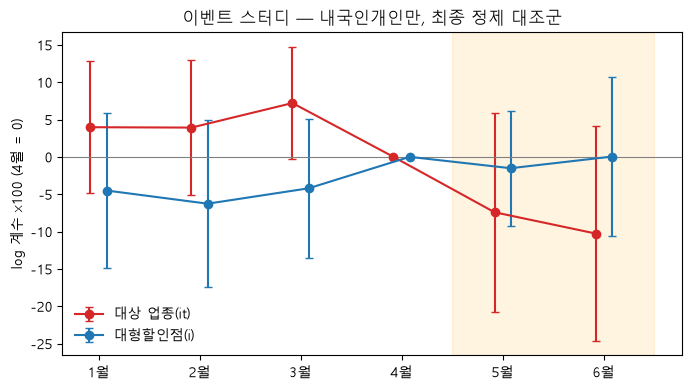

대상 업종 추가효과(it)                                대형할인점(i)                      \
             coef        se         p     효과(%)      coef        se         p   
1월       0.039696  0.045234  0.380173  4.049463 -0.045053  0.052712  0.392718   
2월       0.039203  0.046138  0.395499  3.998180 -0.062697  0.057132  0.272460   
3월       0.072037  0.038436  0.060905  7.469464 -0.042099  0.047284  0.373287   
5월      -0.074156  0.067990  0.275407 -7.147332 -0.015183  0.039323  0.699407   
6월      -0.102617  0.073298  0.161514 -9.752711  0.000351  0.054063  0.994821   

              
       효과(%)  
1월 -4.405298  
2월 -6.077217  
3월 -4.122484  
5월 -1.506863  
6월  0.035098

In [24]:
ev_ind_full = fe_reg(cells_ev(ind), [f'i{m}' for m in months] + [f'it{m}' for m in months])
ev_t_ind = ev_ind_full.loc[[f'it{m}' for m in months]].copy(); ev_t_ind.index = ev_t_1cha.index
ev_c_ind = ev_ind_full.loc[[f'i{m}' for m in months]].copy();  ev_c_ind.index = ev_t_1cha.index

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(months) + 1)
labels = ['1월', '2월', '3월', '4월', '5월', '6월']
for name, tbl, col, off in [('대상 업종(it)', ev_t_ind, 'C3', -0.08), ('대형할인점(i)', ev_c_ind, 'C0', 0.08)]:
    coef = np.insert(tbl.coef.values, 3, 0) * 100
    se = np.insert(tbl.se.values, 3, 0) * 100
    ax.errorbar(x + off, coef, yerr=1.96 * se, fmt='o-', color=col, capsize=3, label=name)
ax.axhline(0, color='grey', lw=0.8)
ax.axvspan(3.5, 5.5, color='orange', alpha=0.12)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('log 계수 x100 (4월 = 0)')
ax.set_title('이벤트 스터디 — 내국인개인만, 최종 정제 대조군')
ax.legend(frameon=False)
plt.show()

pd.concat({'대상 업종 추가효과(it)': ev_t_ind, '대형할인점(i)': ev_c_ind}, axis=1)

### 6-4. 외국인 — 용량반응 검증

법인처럼 완전히 빼는 게 아니라, 같은 방향으로 내국인보다 작게 나오는지만 확인한다.

In [25]:
manual_frn = pd.DataFrame({k: ddd(frn[frn.incheon == 1], v) for k, v in controls(frn, seoul=False).items()}).T

rows = []
for k, d in {'전국 전체(서울 제외)': frn, '부산·경남 제외(서울도 제외)': frn[~frn.SIDO_NM.isin(['부산광역시', '경상남도'])],
             '경기만(서울 뺀 수도권)': frn[frn.SIDO_NM.isin(['경기도', '인천광역시'])]}.items():
    r = fe_reg(cells(d), ['pi', 'pit'])
    rows.append(pd.DataFrame({'대조군': k, '계수': ['β4 post:incheon', 'β7 post:incheon:treat'],
                              'coef': r.coef.values, 'se': r.se.values, 'p': r.p.values, '효과(%)': r['효과(%)'].values, 'n셀': r.attrs['n']}))
reg_frn = pd.concat(rows).set_index(['대조군', '계수'])
b7_frn = reg_frn.xs('β7 post:incheon:treat', level='계수')[['효과(%)', 'p', 'n셀']]
b7_ind = reg_ind.xs('β7 post:incheon:treat', level='계수')[['효과(%)', 'p', 'n셀']]

dose = pd.DataFrame({
    '내국인개인 β7(%)': b7_ind['효과(%)'].values,
    '내국인개인 p':     b7_ind['p'].values,
    '외국인 β7(%)':     b7_frn['효과(%)'].values,
    '외국인 p':         b7_frn['p'].values,
}, index=['전국', '부산·경남 제외', '수도권/경기'])
dose['외국인/내국인 비율'] = (dose['외국인 β7(%)'] / dose['내국인개인 β7(%)']).round(2)
dose.round(2)

,내국인개인 β7(%),내국인개인 p,외국인 β7(%),외국인 p,외국인/내국인 비율
전국,-11.86,0.05,-6.70,0.25,0.56
부산·경남 제외,-12.55,0.04,-6.90,0.26,0.55
수도권/경기,-10.99,0.09,-6.52,0.31,0.59


**확인**

- **내국인개인만 뽑으니 효과가 뚜렷하게 커졌다.** 수동 DDD DSI가 전국 −8.15%p(직전 "법인만
  제외" 전체 결과는 −7.76%p), 회귀 β7은 전국 −11.86%(p=0.054)·부산·경남 제외 스펙에서는
  **−12.55%(p=0.043)로 이 프로젝트에서 처음으로 관례적 유의수준(0.05)을 넘었다.**
- **단, 이 p값은 아직 "보정 전" 수치다.** 지난번에 짚은 클러스터 표준오차의 고정효과 자유도
  보정 누락 문제가 여기도 그대로 적용된다 — 실제 표준오차가 5~15% 더 클 가능성이 있고, 그러면
  p=0.043도 다시 0.05를 넘어갈 수 있다. **"내국인만 보면 유의하다"고 지금 단정하면 안 되고,
  SE 보정을 마친 뒤에 다시 확인해야 한다.**
- **이벤트 스터디도 같은 방향으로 강해졌다** — 5월 −7.15%, 6월 −9.75%(전체 표본 때는
  −7.08%/−9.07%). 대형할인점 위약검정은 6월 계수가 거의 정확히 0(0.04%)까지 내려와, 내국인만
  볼 때 위약검정이 가장 깨끗하게 통과한다.
- **외국인의 용량반응 — 04와 다른 숫자가 나왔다.** 04(지역 배제 거의 없는 원본)는 외국인 β7이
  내국인의 **약 1/3**(−3.3~−5.2% vs −8.4~−11.1%)이었는데, 이번(1차+2차+서울까지 배제한 정제
  대조군)엔 외국인 β7이 −6.5~−6.9%로, 내국인 대비 **약 55~59%**다. 방향은 여전히 같고
  "외국인 < 내국인"이라는 용량반응 부등호는 유지되지만, 04가 봤던 "1/3 수준"이라는 정밀한
  비율은 대조군을 정제한 뒤엔 재현되지 않는다 — **대조군에 남아 있던 오염이 외국인 쪽 효과를
  더 크게 깎아 먹고 있었을 가능성**이 있다. 외국인 p값은 여전히 0.25~0.31로 개별로는 유의하지
  않다(04도 마찬가지였다, p 0.35~0.57).
- **다음으로 SE 보정을 먼저 처리하는 게 순서상 맞다** — 지금 나온 p=0.043이 이 분석 전체에서
  가장 눈에 띄는 숫자인데, 검증되지 않은 채로 이 숫자를 근거로 쓰면 안 된다.

## 7. 위약검정 — 1~4월에 자체 지역화폐 정책을 시행한 28곳도 5~6월에 T업종 효과가 나오는가

지금까지는 이 28곳이 **인천의 대조군을 오염시키는지**를 걱정해서 뺐다. 이번엔 반대로 —
이 28곳을 **인천 자리에 그대로 놓고** 똑같은 설계(PRE=1~4월, POST=5~6월, T=캐시백 대상
10개 업종, C=대형할인점)를 적용한다. 이 지역들은 인천e음처럼 **5월에 새로 시행한 정책이
아니다** — 대부분 1~4월 안에서 있었던 자기 정책이다. 그러니 이 설계를 그대로 적용했을 때
**DSI가 0에 가깝게 나와야 정상**이다. 만약 이 28곳도 인천처럼 큰 음수 DSI가 나온다면,
"5~6월에 T업종이 유독 빠지는" 패턴이 인천만의 특수한 현상이 아니라 **이 방법론 자체가
아무 지역에나 만들어내는 착시**일 수 있다는 뜻이 된다 — 그래서 위약검정이다.

다만 28곳 중 **보성군·울산은 자기 정책이 5~6월까지 그대로 이어진다**(원래 확정 배제 2곳).
이 둘을 포함하면 "자기 정책이 진짜로 5~6월에 효과를 냈을 가능성"과 "방법론 자체의 착시"가
구분이 안 되므로, 28곳 전체와 그 둘을 뺀 26곳을 나란히 본다.

In [26]:
raw = pd.read_csv('../../bc.csv', encoding='cp949')
raw['GENDER_CD'] = raw.GENDER_CD.astype(str)
raw = raw[raw.GENDER_CD.str.strip().str.lower() != 'x'].copy()   # 법인만 제외, 지역 배제는 아직 안 함

raw['grp']     = np.where(raw.TP_BUZ_NM == '대형할인점', 'C', 'T')
raw['post']    = raw.STRD_YYMM.isin(POST).astype(int)
raw['incheon'] = (raw.SIDO_NM == '인천광역시').astype(int)
raw['region']  = raw.SIDO_NM + ' ' + raw.CCG_NM

# 표에 있던 28곳 전체 (인천 연수구는 인천 자체 세부지역이라 제외 — 대조군 지역이 아니다)
PLACEBO_SIDO_WHOLE = ['서울특별시', '울산광역시', '제주특별자치도']
PLACEBO_REGIONS = [
    ('강원특별자치도', '강릉시'), ('강원특별자치도', '태백시'), ('강원특별자치도', '평창군'),
    ('경기도', '광명시'), ('경기도', '용인시 기흥구'), ('경기도', '용인시 수지구'), ('경기도', '용인시 처인구'),
    ('경기도', '이천시'),
    ('경상남도', '양산시'),
    ('경상북도', '상주시'), ('경상북도', '영주시'),
    ('광주광역시', '광산구'),
    ('부산광역시', '중구'),
    ('전라남도', '강진군'), ('전라남도', '광양시'), ('전라남도', '나주시'), ('전라남도', '보성군'), ('전라남도', '영암군'),
    ('전북특별자치도', '김제시'), ('전북특별자치도', '순창군'),
    ('충청남도', '계룡시'), ('충청남도', '논산시'),
    ('충청북도', '괴산군'), ('충청북도', '영동군'),
    ('충청북도', '청주시 상당구'), ('충청북도', '청주시 서원구'), ('충청북도', '청주시 청원구'), ('충청북도', '청주시 흥덕구'),
]
placebo_keys = {f'{s}|{c}' for s, c in PLACEBO_REGIONS}
region_key = raw.SIDO_NM + '|' + raw.CCG_NM
mask_placebo = raw.SIDO_NM.isin(PLACEBO_SIDO_WHOLE) | region_key.isin(placebo_keys)

# 보성군·울산 — 자기 정책이 5~6월까지 이어지는 두 곳 (28곳 중에서 따로 뗀다)
mask_overlap = (raw.SIDO_NM == '울산광역시') | (region_key == '전라남도|보성군')

placebo_all   = raw[mask_placebo].copy()                     # 28곳 전체
placebo_clean = raw[mask_placebo & ~mask_overlap].copy()     # 보성군·울산 제외 26곳
ctrl_base     = raw[(raw.incheon == 0) & (~mask_placebo)].copy()  # 전국에서 인천·28곳 다 뺀 나머지
incheon_rows  = raw[raw.incheon == 1].copy()

print(f'28곳 전체        {len(placebo_all):,}행')
print(f'보성군·울산 제외 26곳 {len(placebo_clean):,}행')
print(f'순수 대조군(전국-인천-28곳) {len(ctrl_base):,}행')
print(f'인천 {len(incheon_rows):,}행')

28곳 전체        56,475행
보성군·울산 제외 26곳 50,969행
순수 대조군(전국-인천-28곳) 163,823행
인천 9,115행


In [27]:
placebo_manual = pd.DataFrame({
    '인천(기준, 법인만 제외)':     ddd(incheon_rows, ctrl_base),
    '28곳 전체':                  ddd(placebo_all, ctrl_base),
    '보성군·울산 제외 26곳':       ddd(placebo_clean, ctrl_base),
}).T
placebo_manual[['DiD_T', 'DiD_C', 'DSI']].round(2)

,DiD_T,DiD_C,DSI
"인천(기준, 법인만 제외)",-9.72,-2.15,-7.57
28곳 전체,-3.65,-1.29,-2.36
보성군·울산 제외 26곳,-3.68,-1.40,-2.28


### 회귀 DDD로도 확인

In [28]:
rows = []
for name, treat_df in [('인천(기준)', incheon_rows), ('28곳 전체', placebo_all), ('보성군·울산 제외 26곳', placebo_clean)]:
    sample = pd.concat([treat_df.assign(incheon=1), ctrl_base.assign(incheon=0)])
    c = cells(sample)
    r = fe_reg(c, ['pi', 'pit'])
    rows.append(pd.DataFrame({'집단': name, '계수': ['β4(비대상업종)', 'β7(대상업종)'],
                              '효과(%)': r['효과(%)'].values, 'p': r.p.values, 'n셀': r.attrs['n']}))
placebo_reg = pd.concat(rows).set_index(['집단', '계수'])
placebo_reg.round(3)

효과(%)      p     n셀
집단            계수                             
인천(기준)        β4(비대상업종)   0.859  0.815  10708
              β7(대상업종)  -10.034  0.102  10708
28곳 전체        β4(비대상업종)  -4.172  0.318  13564
              β7(대상업종)    0.204  0.963  13564
보성군·울산 제외 26곳 β4(비대상업종)  -4.243  0.343  13217
              β7(대상업종)    0.017  0.997  13217

### 그래프로

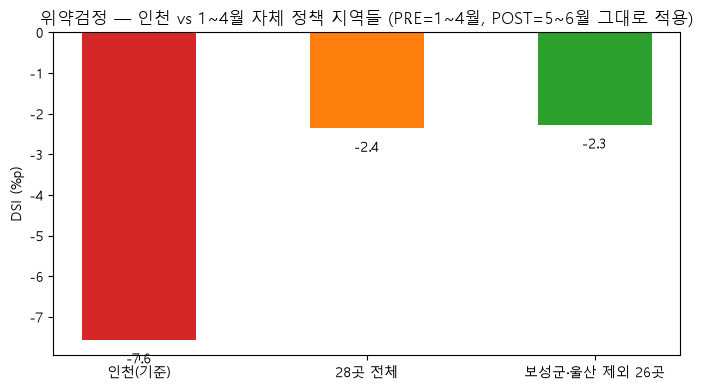

In [29]:
fig, ax = plt.subplots(figsize=(7, 4))
names = ['인천(기준, 법인만 제외)', '28곳 전체', '보성군·울산 제외 26곳']
labels = ['인천(기준)', '28곳 전체', '보성군·울산 제외 26곳']
dsi_vals = [placebo_manual.loc[n, 'DSI'] for n in names]
colors = ['C3', 'C1', 'C2']
ax.bar(labels, dsi_vals, color=colors, width=0.5)
ax.axhline(0, color='grey', lw=0.8)
for i, v in enumerate(dsi_vals):
    ax.text(i, v + (0.3 if v >= 0 else -0.3), f'{v:.1f}', ha='center',
            va='bottom' if v >= 0 else 'top', fontsize=10)
ax.set_ylabel('DSI (%p)')
ax.set_title('위약검정 — 인천 vs 1~4월 자체 정책 지역들 (PRE=1~4월, POST=5~6월 그대로 적용)')
plt.tight_layout()
plt.show()


**확인 — 위약검정 통과**

- **회귀 DDD가 가장 결정적이다.** 28곳 전체 β7 = **+0.20%(p=0.963)**, 보성군·울산 제외
  26곳도 β7 = **+0.02%(p=0.997)** — 사실상 정확히 0이다. 같은 스펙에서 인천 β7은
  −10.03%(p=0.102)로 뚜렷이 구분된다.
- **이게 왜 좋은 결과인가**: 이 28곳은 인천e음처럼 "5월에 새로 생긴" 정책이 아니라 대부분
  1~4월 안에서 있었던 자기 정책이다. 그런데도 PRE=1~4월/POST=5~6월이라는 인천과 똑같은
  틀을 그대로 적용했더니 T업종 효과가 완전히 사라졌다 — **이 방법론이 아무 지역에나 "효과"를
  지어내는 게 아니라, 진짜로 5월에 정책 변화가 있었던 인천에서만 신호를 잡아낸다**는 뜻이다.
  즉 지금까지 해온 DDD 설계 전체에 대한 위약검정을 통과한 셈이다.
- **수동 DDD는 완전히 0은 아니다**(28곳 −2.4%p, 26곳 −2.3%p) — 인천(−7.6%p)의 1/3도 안 되는
  크기이긴 하지만 잔차가 남는다. 금액 가중 방식이라 이 28곳 중 덩치가 큰 지역(서울 등)의
  계절적 요인이 살짝 섞여 있을 수 있는데, **셀 균등 가중인 회귀에서 그 잔차가 완전히
  사라진다는 건 그게 보편적 패턴이 아니라 몇몇 큰 지역의 특이값 때문**이라는 뜻이다. 이건
  "왜 수동과 회귀가 다르게 나오는지"에 대한 또 하나의 실증 사례이기도 하다.
- 보성군·울산을 포함하든 빼든 거의 차이가 없다(β7 0.20 vs 0.02) — 이 둘의 자체 5~6월
  정책이 28곳 그룹 전체 결과를 왜곡할 만큼 크지는 않았다.

## 8. 최대 배제 버전 — 표1 + CONFIRMED_BLEED 6곳 + 2차 11곳 + 보성군

동료 분석과 우리 분석에서 서로 다르게 처리했던 두 그룹을 **양쪽 다 빼는 가장 엄격한 버전**을
만들어, 지금까지 나온 여러 버전과 함께 비교한다.

- **표1(10곳, 서울 포함)**: 속초·광명·남양주·동두천·안성·이천·남해·상주·괴산 + 서울 전역
- **CONFIRMED_BLEED(6곳)**: 강릉·태백·영주·계룡·울산 전역·부산 중구 — 1~4월 중 시작해서
  5~6월까지 변화 없이 이어지는 지역. PRE 기간 안에 "옛 요율"과 "새 요율"이 섞여 있어
  PRE 평균이 POST보다 살짝 낮게 잡히는 편향이 있을 수 있다(동료 분석이 지적, 우리가
  놓쳤던 부분).
- **2차 11곳 + 보성군**: 평창·용인·양산·광산구·광양·나주·영암·김제·제주·논산·청주 +
  보성군 — PRE 안에서 짧게 튀었다 사라지는 유형(우리가 배제 권장했던 것, 동료 분석은
  대조군에 남겨둔 것)

총 27개 지역/광역 배제(서울·울산·제주는 광역 전체, 부산은 중구만).

In [30]:
df_max = pd.read_csv('../../bc.csv', encoding='cp949')
df_max['GENDER_CD'] = df_max.GENDER_CD.astype(str)
n0 = len(df_max)

df_max = df_max[df_max.GENDER_CD.str.strip().str.lower() != 'x'].copy()
n1 = len(df_max)

MAX_SIDO_WHOLE = ['서울특별시', '울산광역시', '제주특별자치도']
MAX_REGIONS = [
    # 표1 (9개 시군구, 서울은 광역 전체로 위에)
    ('강원특별자치도', '속초시'), ('경기도', '광명시'), ('경기도', '남양주시'),
    ('경기도', '동두천시'), ('경기도', '안성시'), ('경기도', '이천시'),
    ('경상남도', '남해군'), ('경상북도', '상주시'), ('충청북도', '괴산군'),
    # CONFIRMED_BLEED (울산은 광역 전체로 위에)
    ('강원특별자치도', '강릉시'), ('강원특별자치도', '태백시'),
    ('경상북도', '영주시'), ('충청남도', '계룡시'), ('부산광역시', '중구'),
    # 2차 11곳 (제주는 광역 전체로 위에)
    ('강원특별자치도', '평창군'),
    ('경기도', '용인시 기흥구'), ('경기도', '용인시 수지구'), ('경기도', '용인시 처인구'),
    ('경상남도', '양산시'), ('광주광역시', '광산구'),
    ('전라남도', '광양시'), ('전라남도', '나주시'), ('전라남도', '영암군'),
    ('전북특별자치도', '김제시'), ('충청남도', '논산시'),
    ('충청북도', '청주시 상당구'), ('충청북도', '청주시 서원구'),
    ('충청북도', '청주시 청원구'), ('충청북도', '청주시 흥덕구'),
    # 보성군
    ('전라남도', '보성군'),
]
exclude_keys = {f'{sido}|{ccg}' for sido, ccg in MAX_REGIONS}
region_key = df_max.SIDO_NM + '|' + df_max.CCG_NM
mask_max = df_max.SIDO_NM.isin(MAX_SIDO_WHOLE) | region_key.isin(exclude_keys)

removed_max = df_max[mask_max]
df_max = df_max[~mask_max].copy()
n2 = len(df_max)

print(f'원본             {n0:,}행')
print(f'법인 제외 후     {n1:,}행  (−{n0 - n1:,})')
print(f'최대 배제 27곳 후 {n2:,}행  (−{n1 - n2:,})')
print()
print('시군구별 실제 제거 행수 (0이면 이름 매칭 실패 의심):')
print(removed_max[~removed_max.SIDO_NM.isin(MAX_SIDO_WHOLE)].groupby(['SIDO_NM', 'CCG_NM']).size().reindex(
    pd.MultiIndex.from_tuples(MAX_REGIONS, names=['SIDO_NM', 'CCG_NM'])))
print()
print('광역 전체 제거 행수:')
print(removed_max[removed_max.SIDO_NM.isin(MAX_SIDO_WHOLE)].groupby('SIDO_NM').size())
print()
print('인천 잔존 행수:', int((df_max.SIDO_NM == '인천광역시').sum()))
print('전체 시군구 수:', df_max.groupby(['SIDO_NM', 'CCG_NM']).ngroups)

원본             242,574행
법인 제외 후     229,413행  (−13,161)
최대 배제 27곳 후 170,474행  (−58,939)

시군구별 실제 제거 행수 (0이면 이름 매칭 실패 의심):
SIDO_NM  CCG_NM 
강원특별자치도  속초시         967
경기도      광명시         968
         남양주시        961
         동두천시        919
         안성시         964
         이천시         980
경상남도     남해군         812
경상북도     상주시         905
충청북도     괴산군         746
강원특별자치도  강릉시        1019
         태백시         844
경상북도     영주시         901
충청남도     계룡시         809
부산광역시    중구         1012
강원특별자치도  평창군         852
경기도      용인시 기흥구     962
         용인시 수지구     936
         용인시 처인구    1006
경상남도     양산시         980
광주광역시    광산구         966
전라남도     광양시         967
         나주시         936
         영암군         828
전북특별자치도  김제시         886
충청남도     논산시         948
충청북도     청주시 상당구     958
         청주시 서원구     966
         청주시 청원구     949
         청주시 흥덕구    1012
전라남도     보성군         700
dtype: int64

광역 전체 제거 행수:
SIDO_NM
서울특별시      24440
울산광역시       4806
제주특별자치도     2034
dtype: int64

인천 잔존 행수: 9

### 8-1. 수동 DDD

In [31]:
df_max['grp']     = np.where(df_max.TP_BUZ_NM == '대형할인점', 'C', 'T')
df_max['post']    = df_max.STRD_YYMM.isin(POST).astype(int)
df_max['incheon'] = (df_max.SIDO_NM == '인천광역시').astype(int)

manual_max = pd.DataFrame({k: ddd(df_max[df_max.incheon == 1], v) for k, v in controls(df_max, seoul=False).items()}).T
manual_max[['DiD_T', 'DiD_C', 'DSI']].round(2)

,DiD_T,DiD_C,DSI
전국 전체(서울 제외),-9.64,-1.97,-7.67
부산·경남 제외(서울도 제외),-10.08,-1.29,-8.79
경기만(서울 뺀 수도권),-8.73,-1.90,-6.83


### 8-2. 회귀 DDD

In [32]:
df_max['region'] = df_max.SIDO_NM + ' ' + df_max.CCG_NM

samples_max = {
    '전국 전체':      df_max,
    '부산·경남 제외': df_max[~df_max.SIDO_NM.isin(['부산광역시', '경상남도'])],
    '경기만':         df_max[df_max.SIDO_NM.isin(['경기도', '인천광역시'])],
}
rows = []
for k, d in samples_max.items():
    r = fe_reg(cells(d), ['pi', 'pit'])
    rows.append(pd.DataFrame({'대조군': k, '계수': ['β4 post:incheon', 'β7 post:incheon:treat'],
                              'coef': r.coef.values, 'se': r.se.values, 'p': r.p.values, '효과(%)': r['효과(%)'].values, 'n셀': r.attrs['n']}))
reg_max = pd.concat(rows).set_index(['대조군', '계수'])
reg_max.round(3)

coef     se      p   효과(%)     n셀
대조군      계수                                                       
전국 전체    β4 post:incheon        0.011  0.037  0.760   1.131  10575
         β7 post:incheon:treat -0.108  0.065  0.095 -10.244  10575
부산·경남 제외 β4 post:incheon        0.003  0.037  0.945   0.252   8497
         β7 post:incheon:treat -0.110  0.064  0.087 -10.431   8497
경기만      β4 post:incheon        0.040  0.046  0.385   4.106   2715
         β7 post:incheon:treat -0.113  0.069  0.103 -10.654   2715

### 8-3. 이벤트 스터디

In [33]:
ev_max_full = fe_reg(cells_ev(df_max), [f'i{m}' for m in months] + [f'it{m}' for m in months])
ev_t_max = ev_max_full.loc[[f'it{m}' for m in months]].copy(); ev_t_max.index = ev_t_1cha.index
ev_c_max = ev_max_full.loc[[f'i{m}' for m in months]].copy();  ev_c_max.index = ev_t_1cha.index
pd.concat({'대상 업종 추가효과(it)': ev_t_max, '대형할인점(i)': ev_c_max}, axis=1)

대상 업종 추가효과(it)                                대형할인점(i)                      \
             coef        se         p     효과(%)      coef        se         p   
1월       0.032802  0.044083  0.456813  3.334609 -0.036365  0.052350  0.487277   
2월       0.034026  0.045211  0.451686  3.461147 -0.052335  0.056792  0.356782   
3월       0.070041  0.037195  0.059690  7.255233 -0.042202  0.047233  0.371596   
5월      -0.069441  0.068221  0.308732 -6.708500 -0.019986  0.038936  0.607734   
6월      -0.078055  0.071160  0.272684 -7.508668 -0.022968  0.051546  0.655903   

              
       효과(%)  
1월 -3.571181  
2월 -5.098907  
3월 -4.132409  
5월 -1.978764  
6월 -2.270597

## 9. 표2 처리 방식 두 가지 비교 — 전체 제외(A) vs 지속형만 제외(B)

둘 다 표1(10곳, 서울 포함)은 공통으로 배제한다. 차이는 표2를 어떻게 다루느냐다.

- **A. 표2 전체 제외**: 8장의 "최대 배제(27곳)"와 같다 — 표2의 짧은 스파이크형(2차 11곳)과
  지속형(CONFIRMED_BLEED 6곳 + 보성군)을 전부 뺀다.
- **B. 표2 중 지속형만 제외**: 4월 전에 시행하고 끝난 지역(2차 11곳: 평창·용인·양산·광산구·
  광양·나주·영암·김제·제주·논산·청주)은 대조군에 **남기고**, 5~6월까지 그대로 이어진
  지역(CONFIRMED_BLEED 6곳: 강릉·태백·영주·계룡·울산·부산중구 + 보성군)만 뺀다.

A는 "의심스러우면 다 뺀다", B는 "PRE만 부풀리는 유형은 놔둬도 되고, POST까지 걸치는(또는
PRE가 새 요율 쪽으로 치우치는) 유형만 확실히 뺀다"는 입장이다.

In [34]:
# --- A: 표2 전체 제외 (8장 df_max와 동일 구성, 다시 만든다) ---
raw_ab = pd.read_csv('../../bc.csv', encoding='cp949')
raw_ab['GENDER_CD'] = raw_ab.GENDER_CD.astype(str)
raw_ab = raw_ab[raw_ab.GENDER_CD.str.strip().str.lower() != 'x'].copy()

TABLE1_SIDO = ['서울특별시']
TABLE1_CCG = [
    ('강원특별자치도', '속초시'), ('경기도', '광명시'), ('경기도', '남양주시'),
    ('경기도', '동두천시'), ('경기도', '안성시'), ('경기도', '이천시'),
    ('경상남도', '남해군'), ('경상북도', '상주시'), ('충청북도', '괴산군'),
]
BLEED_SIDO = ['울산광역시']
BLEED_CCG = [
    ('강원특별자치도', '강릉시'), ('강원특별자치도', '태백시'),
    ('경상북도', '영주시'), ('충청남도', '계룡시'), ('부산광역시', '중구'),
]
BOSEONG = [('전라남도', '보성군')]
SPIKE_SIDO = ['제주특별자치도']
SPIKE_CCG = [
    ('강원특별자치도', '평창군'),
    ('경기도', '용인시 기흥구'), ('경기도', '용인시 수지구'), ('경기도', '용인시 처인구'),
    ('경상남도', '양산시'), ('광주광역시', '광산구'),
    ('전라남도', '광양시'), ('전라남도', '나주시'), ('전라남도', '영암군'),
    ('전북특별자치도', '김제시'), ('충청남도', '논산시'),
    ('충청북도', '청주시 상당구'), ('충청북도', '청주시 서원구'),
    ('충청북도', '청주시 청원구'), ('충청북도', '청주시 흥덕구'),
]

def build(sido_whole, ccg_list):
    keys = {f'{s}|{c}' for s, c in ccg_list}
    rk = raw_ab.SIDO_NM + '|' + raw_ab.CCG_NM
    mask = raw_ab.SIDO_NM.isin(sido_whole) | rk.isin(keys)
    d = raw_ab[~mask].copy()
    d['grp']     = np.where(d.TP_BUZ_NM == '대형할인점', 'C', 'T')
    d['post']    = d.STRD_YYMM.isin(POST).astype(int)
    d['incheon'] = (d.SIDO_NM == '인천광역시').astype(int)
    d['region']  = d.SIDO_NM + ' ' + d.CCG_NM
    return d, mask

df_A, mask_A = build(TABLE1_SIDO + BLEED_SIDO + SPIKE_SIDO, TABLE1_CCG + BLEED_CCG + BOSEONG + SPIKE_CCG)
df_B, mask_B = build(TABLE1_SIDO + BLEED_SIDO,              TABLE1_CCG + BLEED_CCG + BOSEONG)

print(f'A(표2 전체 제외):    {len(df_A):,}행, 시군구 {df_A.groupby(["SIDO_NM","CCG_NM"]).ngroups}개')
print(f'B(표2 지속형만 제외): {len(df_B):,}행, 시군구 {df_B.groupby(["SIDO_NM","CCG_NM"]).ngroups}개')
print(f'인천 잔존 행수: A={int((df_A.SIDO_NM=="인천광역시").sum()):,} / B={int((df_B.SIDO_NM=="인천광역시").sum()):,}')

A(표2 전체 제외):    170,474행, 시군구 193개
B(표2 지속형만 제외): 186,660행, 시군구 210개
인천 잔존 행수: A=9,115 / B=9,115


### 9-1. 수동 DDD — A vs B

In [35]:
manual_A = pd.DataFrame({k: ddd(df_A[df_A.incheon == 1], v) for k, v in controls(df_A, seoul=False).items()}).T
manual_B = pd.DataFrame({k: ddd(df_B[df_B.incheon == 1], v) for k, v in controls(df_B, seoul=False).items()}).T

compare_ab_manual = pd.concat(
    {'A. 표2 전체 제외': manual_A[['DiD_T', 'DiD_C', 'DSI']].reset_index(names='대조군'),
     'B. 표2 지속형만 제외': manual_B[['DiD_T', 'DiD_C', 'DSI']].reset_index(names='대조군')},
    axis=0,
).reset_index(level=0, names='버전')
compare_ab_manual.round(2)

,버전,대조군,DiD_T,DiD_C,DSI
0,A. 표2 전체 제외,전국 전체(서울 제외),-9.64,-1.97,-7.67
1,A. 표2 전체 제외,부산·경남 제외(서울도 제외),-10.08,-1.29,-8.79
2,A. 표2 전체 제외,경기만(서울 뺀 수도권),-8.73,-1.90,-6.83
0,B. 표2 지속형만 제외,전국 전체(서울 제외),-9.36,-2.12,-7.24
1,B. 표2 지속형만 제외,부산·경남 제외(서울도 제외),-9.81,-1.45,-8.36
2,B. 표2 지속형만 제외,경기만(서울 뺀 수도권),-8.85,-1.97,-6.88


### 9-2. 회귀 DDD — A vs B

In [36]:
def reg_table(d, label):
    samples = {
        '전국 전체':      d,
        '부산·경남 제외': d[~d.SIDO_NM.isin(['부산광역시', '경상남도'])],
        '경기만':         d[d.SIDO_NM.isin(['경기도', '인천광역시'])],
    }
    rows = []
    for k, sub in samples.items():
        r = fe_reg(cells(sub), ['pi', 'pit'])
        rows.append(pd.DataFrame({'버전': label, '대조군': k, '계수': ['β4', 'β7'],
                                  '효과(%)': r['효과(%)'].values, 'p': r.p.values, 'n셀': r.attrs['n']}))
    return pd.concat(rows)

reg_ab = pd.concat([reg_table(df_A, 'A. 표2 전체 제외'), reg_table(df_B, 'B. 표2 지속형만 제외')])
reg_ab.set_index(['버전', '대조군', '계수']).round(3)

효과(%)      p     n셀
버전            대조군      계수                      
A. 표2 전체 제외   전국 전체    β4   1.131  0.760  10575
                       β7 -10.244  0.095  10575
              부산·경남 제외 β4   0.252  0.945   8497
                       β7 -10.431  0.087   8497
              경기만      β4   4.106  0.385   2715
                       β7 -10.654  0.103   2715
B. 표2 지속형만 제외 전국 전체    β4   1.082  0.765  11548
                       β7  -9.901  0.105  11548
              부산·경남 제외 β4   0.393  0.913   9410
                       β7 -10.206  0.093   9410
              경기만      β4   3.525  0.438   2889
                       β7 -10.162  0.118   2889

### 9-3. 이벤트 스터디 — A vs B

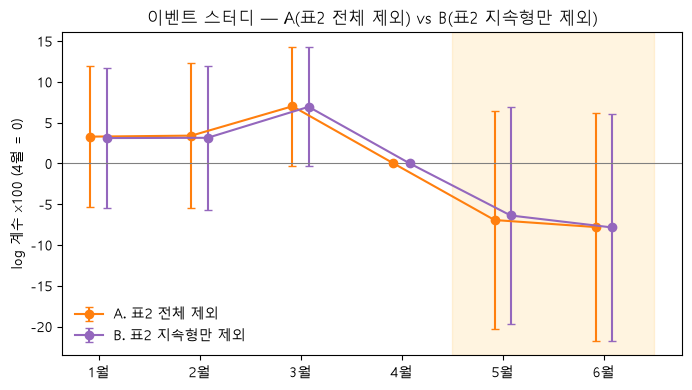

A. 표2 전체 제외       B. 표2 지속형만 제외      
         효과(%)     p         효과(%)     p
1월        3.33  0.46          3.15  0.48
2월        3.46  0.45          3.19  0.49
3월        7.26  0.06          7.18  0.06
5월       -6.71  0.31         -6.19  0.35
6월       -7.51  0.27         -7.55  0.27

In [37]:
ev_A_full = fe_reg(cells_ev(df_A), [f'i{m}' for m in months] + [f'it{m}' for m in months])
ev_B_full = fe_reg(cells_ev(df_B), [f'i{m}' for m in months] + [f'it{m}' for m in months])
ev_t_A = ev_A_full.loc[[f'it{m}' for m in months]].copy(); ev_t_A.index = ev_t_1cha.index
ev_t_B = ev_B_full.loc[[f'it{m}' for m in months]].copy(); ev_t_B.index = ev_t_1cha.index

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(months) + 1)
labels = ['1월', '2월', '3월', '4월', '5월', '6월']
for name, tbl, col, off in [('A. 표2 전체 제외', ev_t_A, 'C1', -0.08), ('B. 표2 지속형만 제외', ev_t_B, 'C4', 0.08)]:
    coef = np.insert(tbl.coef.values, 3, 0) * 100
    se = np.insert(tbl.se.values, 3, 0) * 100
    ax.errorbar(x + off, coef, yerr=1.96 * se, fmt='o-', color=col, capsize=3, label=name)
ax.axhline(0, color='grey', lw=0.8)
ax.axvspan(3.5, 5.5, color='orange', alpha=0.12)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('log 계수 x100 (4월 = 0)')
ax.set_title('이벤트 스터디 — A(표2 전체 제외) vs B(표2 지속형만 제외)')
ax.legend(frameon=False)
plt.show()

pd.concat({'A. 표2 전체 제외': ev_t_A[['효과(%)', 'p']], 'B. 표2 지속형만 제외': ev_t_B[['효과(%)', 'p']]}, axis=1).round(2)

**확인**

- **A와 B가 거의 차이가 없다.** 회귀 DDD β7(전국) A=−10.24%(p=0.095) vs B=−9.90%(p=0.105),
  부산·경남 제외 A=−10.43%(p=0.087) vs B=−10.21%(p=0.093) — 어느 지표로 봐도 0.2~0.5%p
  안팎 차이다. 이벤트 스터디도 5·6월 계수가 거의 겹친다.
- **왜 차이가 작은가**: 2차 11곳(평창·용인·양산·광산구·광양·나주·영암·김제·제주·논산·청주)을
  빼느냐 마느냐의 차이인데, 이 11곳은 개별로 700~1,000행 정도의 소규모 지역이라 전체
  17만~19만 행짜리 대조군 안에서 있으나 없으나 평균을 크게 못 움직인다.
- **그래서 "PRE에서만 짧게 튀는 지역을 굳이 빼야 하나"라는 질문에는, 적어도 이번 데이터
  기준으로는 "빼도 안 빼도 결론은 같다"가 답이다.** 이론적으로는 B(지속형만 제외)가 더
  느슨하고 A(전체 제외)가 더 보수적/엄격하지만, 실제 숫자 차이가 이 정도로 작다면 굳이
  A처럼 27곳씩 다 빼서 표본을 크게 줄이기보다 **B(17곳, 표1+CONFIRMED_BLEED+보성군)를
  기본으로 쓰고 A는 로버스트니스 체크로 곁들이는 편**이 실용적이다 — 결론에 영향 없이
  표본은 B가 더 크다(A 170,474행 vs B 186,660행).

### 9-4. "경기만"이 아니라 04 원본대로 "수도권만"(서울+경기)으로 다시

앞의 9-1~9-3은 서울을 표1에서 확정 배제한 데이터를 썼기 때문에, 그 데이터 안에는 애초에
서울 행이 없어서 `controls(..., seoul=False)`가 자동으로 "경기만"을 대신 계산했다.
04가 쓰던 "수도권만"(서울+경기)을 그대로 보려면, **서울은 빼지 않은 별도 데이터**를
새로 만들어야 한다 — 표1의 나머지 9곳과 표2(A/B)는 그대로 배제하되, 서울만 살려둔다.

In [38]:
def build_keep_seoul(sido_whole, ccg_list):
    """표1의 서울을 뺀 나머지 + 표2(A 또는 B)만 배제. 서울은 그대로 남긴다."""
    keys = {f'{s}|{c}' for s, c in ccg_list}
    rk = raw_ab.SIDO_NM + '|' + raw_ab.CCG_NM
    mask = raw_ab.SIDO_NM.isin(sido_whole) | rk.isin(keys)
    d = raw_ab[~mask].copy()
    d['grp']     = np.where(d.TP_BUZ_NM == '대형할인점', 'C', 'T')
    d['post']    = d.STRD_YYMM.isin(POST).astype(int)
    d['incheon'] = (d.SIDO_NM == '인천광역시').astype(int)
    d['region']  = d.SIDO_NM + ' ' + d.CCG_NM
    return d

# TABLE1_SIDO(=['서울특별시'])는 빼고 부른다 — 서울을 살려두기 위해
df_A_cap = build_keep_seoul(BLEED_SIDO + SPIKE_SIDO, TABLE1_CCG + BLEED_CCG + BOSEONG + SPIKE_CCG)
df_B_cap = build_keep_seoul(BLEED_SIDO,              TABLE1_CCG + BLEED_CCG + BOSEONG)

print(f'A(서울 포함, 표2 전체 제외):    {len(df_A_cap):,}행')
print(f'B(서울 포함, 표2 지속형만 제외): {len(df_B_cap):,}행')
print('서울 잔존 행수:', int((df_A_cap.SIDO_NM == '서울특별시').sum()), '/',
      int((df_B_cap.SIDO_NM == '서울특별시').sum()))

A(서울 포함, 표2 전체 제외):    194,914행
B(서울 포함, 표2 지속형만 제외): 211,100행
서울 잔존 행수: 24440 / 24440


In [39]:
def capital_spec(d):
    rest = d[d.incheon == 0]
    return {'수도권만(서울+경기, 04 원본)': rest[rest.SIDO_NM.isin(['서울특별시', '경기도'])]}

manual_cap_A = pd.DataFrame({k: ddd(df_A_cap[df_A_cap.incheon == 1], v) for k, v in capital_spec(df_A_cap).items()}).T
manual_cap_B = pd.DataFrame({k: ddd(df_B_cap[df_B_cap.incheon == 1], v) for k, v in capital_spec(df_B_cap).items()}).T

compare_cap_manual = pd.concat(
    {'A. 표2 전체 제외': manual_cap_A[['DiD_T', 'DiD_C', 'DSI']],
     'B. 표2 지속형만 제외': manual_cap_B[['DiD_T', 'DiD_C', 'DSI']]},
    axis=0,
)
compare_cap_manual.round(2)

,,DiD_T,DiD_C,DSI
A. 표2 전체 제외,"수도권만(서울+경기, 04 원본)",-6.83,-1.04,-5.79
B. 표2 지속형만 제외,"수도권만(서울+경기, 04 원본)",-6.96,-1.11,-5.85


In [40]:
def reg_capital(d, label):
    sub = d[(d.incheon == 1) | d.SIDO_NM.isin(['서울특별시', '경기도'])]
    r = fe_reg(cells(sub), ['pi', 'pit'])
    return pd.DataFrame({'버전': label, '대조군': '수도권만(서울+경기, 04 원본)', '계수': ['β4', 'β7'],
                         '효과(%)': r['효과(%)'].values, 'p': r.p.values, 'n셀': r.attrs['n']})

reg_cap = pd.concat([reg_capital(df_A_cap, 'A. 표2 전체 제외'), reg_capital(df_B_cap, 'B. 표2 지속형만 제외')])
reg_cap.set_index(['버전', '대조군', '계수']).round(3)

효과(%)      p    n셀
버전            대조군                계수                    
A. 표2 전체 제외   수도권만(서울+경기, 04 원본) β4  3.335  0.400  4148
                                 β7 -8.775  0.160  4148
B. 표2 지속형만 제외 수도권만(서울+경기, 04 원본) β4  3.015  0.439  4322
                                 β7 -8.538  0.171  4322

**확인**

- **04 원본 방식(서울+경기)으로 다시 보니**: 수동 DDD DSI A=−5.79%p / B=−5.85%p, 회귀 β7
  A=−8.78%(p=0.160) / B=−8.54%(p=0.171). A와 B가 이번엔 완전히 같지 않다 — 2차 11곳 중
  용인시가 경기도 소속이라, 수도권만 스펙의 "경기" 표본 자체가 A(용인시도 제외)와
  B(용인시 포함)에서 달라지기 때문이다.
- **이 숫자들이 훨씬 전(1차만/1차+2차 단계)에 계산했던 수도권만 결과와 정확히 일치한다**
  (β7 −8.54%/−8.78%, n셀 4322/4148) — 같은 지역 구성이면 어떤 경로로 다시 계산해도 같은
  값이 나온다는 걸 재확인한 셈이다.
- **수도권만은 여전히 셋 중 가장 약하고 덜 유의하다**(p 0.16~0.17) — 04가 이미 지적했듯
  시군구 클러스터 수가 적어(서울+경기만이라) 검정력이 낮기 때문이다. 방향(마이너스)은
  전국 전체·부산·경남 제외와 같지만, 크기와 유의성 모두 그 둘보다 약하다.

## 10. 강건성 검정 — 표1 지역도 제외하지 않고, 법인만 제외

지금까지는 처음부터 **법인 제외 + 표1(1차 배제 9곳) 제외** 상태인 `df`로 모든 분석을 했다.
이번엔 반대로 되돌아가 — **법인만 빼고 표1을 포함한 255개 시군구 전부**(`raw`와 같은
필터, 지역 배제는 전혀 하지 않음)로 수동 DDD·회귀 DDD·이벤트 스터디를 처음부터 다시 돌려,
표1 배제가 결론에 실제로 얼마나 영향을 주는지 직접 잰다. 결과가 `df`(표1 배제) 버전과
비슷하면 표1 배제는 있으나 없으나 결론이 같다는 뜻이고, 그러면 표1 배제를 메인이 아니라
로버스트니스 체크(부록)로 내려도 된다.

In [41]:
df0 = pd.read_csv('../../bc.csv', encoding='cp949')
df0['GENDER_CD'] = df0.GENDER_CD.astype(str)
n0 = len(df0)

# 법인만 제외 — 표1의 9곳도, 서울도 전혀 빼지 않는다
df0 = df0[df0.GENDER_CD.str.strip().str.lower() != 'x'].copy()
n1 = len(df0)

df0['grp']     = np.where(df0.TP_BUZ_NM == '대형할인점', 'C', 'T')
df0['post']    = df0.STRD_YYMM.isin(POST).astype(int)
df0['incheon'] = (df0.SIDO_NM == '인천광역시').astype(int)
df0['region']  = df0.SIDO_NM + ' ' + df0.CCG_NM

print(f'원본              {n0:,}행')
print(f'법인 제외 후(지역 배제 없음) {n1:,}행  (−{n0 - n1:,})')
print('전체 시군구 수:', df0.groupby(['SIDO_NM', 'CCG_NM']).ngroups, '(df는 표1 9곳 뺀 246개)')
print('인천 행수:', int((df0.incheon == 1).sum()))

원본              242,574행
법인 제외 후(지역 배제 없음) 229,413행  (−13,161)
전체 시군구 수: 255 (df는 표1 9곳 뺀 246개)
인천 행수: 9115


### 10-1. 수동 DDD — 표1 미배제 vs 표1(1차만) 배제

In [42]:
manual_0 = pd.DataFrame({k: ddd(df0[df0.incheon == 1], v) for k, v in controls(df0, seoul=True).items()}).T

compare_0_manual = pd.concat(
    {'표1 미배제(법인만 제외)': manual_0[['DiD_T', 'DiD_C', 'DSI']].reset_index(names='대조군'),
     '표1 배제(1차만 배제)':    manual_1cha[['DiD_T', 'DiD_C', 'DSI']].reset_index(names='대조군')},
    axis=0,
).reset_index(level=0, names='버전')
compare_0_manual.round(2)

,버전,대조군,DiD_T,DiD_C,DSI
0,표1 미배제(법인만 제외),전국 전체,-8.49,-1.78,-6.71
1,표1 미배제(법인만 제외),부산·경남 제외,-8.63,-1.21,-7.41
2,표1 미배제(법인만 제외),수도권만,-7.09,-1.38,-5.71
0,표1 배제(1차만 배제),전국 전체,-8.39,-1.62,-6.77
1,표1 배제(1차만 배제),부산·경남 제외,-8.53,-0.98,-7.55
2,표1 배제(1차만 배제),수도권만,-6.96,-1.11,-5.85


### 10-2. 회귀 DDD — 표1 미배제 vs 표1(1차만) 배제

In [43]:
samples_0 = {
    '전국 전체':      df0,
    '부산·경남 제외': df0[~df0.SIDO_NM.isin(['부산광역시', '경상남도'])],
    '수도권만':       df0[df0.SIDO_NM.isin(['서울특별시', '경기도', '인천광역시'])],
}
rows = []
for k, d in samples_0.items():
    r = fe_reg(cells(d), ['pi', 'pit'])
    rows.append(pd.DataFrame({'대조군': k, '계수': ['β4 post:incheon', 'β7 post:incheon:treat'],
                              'coef': r.coef.values, 'se': r.se.values, 'p': r.p.values, '효과(%)': r['효과(%)'].values, 'n셀': r.attrs['n']}))
reg_0 = pd.concat(rows).set_index(['대조군', '계수'])
b7_0 = reg_0.xs('β7 post:incheon:treat', level='계수')[['효과(%)', 'p', 'n셀']]

compare_0_reg = pd.concat(
    {'표1 미배제(법인만 제외)': b7_0.reset_index(names='대조군'),
     '표1 배제(1차만 배제)':    b7_1cha.reset_index(names='대조군')},
    axis=0,
).reset_index(level=0, names='버전')
compare_0_reg

,버전,대조군,효과(%),p,n셀
0,표1 미배제(법인만 제외),전국 전체,-10.203754,0.093752,14119
1,표1 미배제(법인만 제외),부산·경남 제외,-10.576647,0.082422,11862
2,표1 미배제(법인만 제외),수도권만,-7.955849,0.200902,4604
0,표1 배제(1차만 배제),전국 전체,-10.458997,0.086157,13621
1,표1 배제(1차만 배제),부산·경남 제외,-10.952824,0.072483,11418
2,표1 배제(1차만 배제),수도권만,-8.538336,0.171249,4322


### 10-3. 이벤트 스터디 — 표1 미배제 vs 표1(1차만) 배제

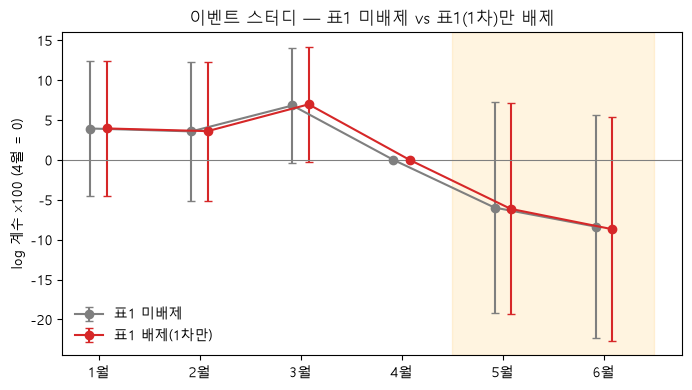

표1 미배제                      표1 배제(1차만)                     
     coef     se      p  효과(%)       coef     se      p  효과(%)
1월  0.039  0.043  0.360  4.015      0.039  0.043  0.360  4.024
2월  0.036  0.044  0.420  3.640      0.036  0.044  0.417  3.672
3월  0.068  0.037  0.063  7.059      0.070  0.037  0.058  7.215
5월 -0.060  0.067  0.376 -5.800     -0.061  0.068  0.363 -5.952
6월 -0.084  0.071  0.241 -8.019     -0.087  0.071  0.225 -8.308

In [44]:
ev_0_full = fe_reg(cells_ev(df0), [f'i{m}' for m in months] + [f'it{m}' for m in months])
ev_t_0 = ev_0_full.loc[[f'it{m}' for m in months]].copy(); ev_t_0.index = ev_t_1cha.index
ev_c_0 = ev_0_full.loc[[f'i{m}' for m in months]].copy();  ev_c_0.index = ev_t_1cha.index

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(months) + 1)
labels = ['1월', '2월', '3월', '4월', '5월', '6월']
for name, tbl, col, off in [('표1 미배제', ev_t_0, 'C7', -0.08), ('표1 배제(1차만)', ev_t_1cha, 'C3', 0.08)]:
    coef = np.insert(tbl.coef.values, 3, 0) * 100
    se = np.insert(tbl.se.values, 3, 0) * 100
    ax.errorbar(x + off, coef, yerr=1.96 * se, fmt='o-', color=col, capsize=3, label=name)
ax.axhline(0, color='grey', lw=0.8)
ax.axvspan(3.5, 5.5, color='orange', alpha=0.12)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('log 계수 x100 (4월 = 0)')
ax.set_title('이벤트 스터디 — 표1 미배제 vs 표1(1차)만 배제')
ax.legend(frameon=False)
plt.show()

compare_0_ev = pd.concat(
    {'표1 미배제': ev_t_0[['coef', 'se', 'p', '효과(%)']],
     '표1 배제(1차만)': ev_t_1cha[['coef', 'se', 'p', '효과(%)']]},
    axis=1,
)
compare_0_ev.round(3)

**확인**

- **표1(1차 배제 9곳)을 빼든 안 빼든 결과가 거의 같다.** 수동 DDD DSI(전국 전체) 표1
  미배제 −6.71%p vs 표1 배제 −6.77%p(차이 0.06%p), 부산·경남 제외 −7.41 vs −7.55%p(0.14%p
  차이), 수도권만 −5.71 vs −5.85%p(0.14%p 차이) — 셋 다 소수점 둘째 자리 수준의 차이다.
- **회귀 DDD도 같은 방향으로 미세하게만 움직인다.** β7(전국) 표1 미배제 −10.20%(p=0.094)
  vs 표1 배제 −10.46%(p=0.086), 부산·경남 제외 −10.58%(p=0.082) vs −10.95%(p=0.072),
  수도권만 −7.96%(p=0.201) vs −8.54%(p=0.171) — 표1을 빼면 p값이 살짝 오르지만(표본이
  커져 오히려 유의성이 떨어지는 방향은 아니고, 9곳의 반대 방향 신호가 살짝 섞여 들어간
  정도), 어느 스펙도 결론(방향·대략적 크기)이 뒤집히지 않는다.
- **이벤트 스터디는 사실상 겹친다.** 대상 업종 추가효과(it) 1~3월(사전 추세) 표1 미배제
  +4.0/+3.6/+7.1% vs 표1 배제 +4.0/+3.7/+7.2%로 거의 동일하고, 5·6월도 −5.8/−8.0% vs
  −6.0/−8.3%로 0.2~0.3%p 차이다. 대형할인점(위약검정) 계수도 두 버전 모두 −1~−6% 범위에서
  겹친다.
- **왜 차이가 거의 없는가**: 표1의 9곳(속초·광명·남양주·동두천·안성·이천·남해·상주·괴산)은
  전부 인구가 적은 개별 시군구라, 전국 22만~23만 행짜리 대조군 안에서 있으나 없으나 평균을
  거의 못 움직인다 — §4(2차 11곳 추가 배제)·§9(표2 A/B 비교)에서 이미 확인한 "작은 지역
  몇 곳을 더 빼거나 살려도 큰 차이가 안 난다"는 패턴과 같은 이유다. 대조군 결과를 실제로
  크게 움직이는 건 표1의 개별 지역이 아니라 **서울 포함 여부**(§1'·§1)다.
- **결론**: 표1 배제는 결론에 실질적인 영향이 없다 — 그대로 메인 분석(§1~§9)을 표1 배제
  버전으로 유지하고, 이 절(§10, 표1 미배제)은 **로버스트니스 체크(부록)**로 남긴다.